# Secondary cracking after a sudden fracture event — theory

Companion notebook to [`problems/secondary.py`](secondary.py), following the concept note (A.L.B., 1st June 2026).

## The question

> When a crack suddenly appears in a thin film glued to a substrate, can the sudden release of stress create more cracks?

The question is simple, but it holds the main ingredients of dynamic fracture: **stored elastic energy is released all at once**, **waves travel**, **they reflect at the boundaries**, **they are damped**, and **a cracking rule may switch on again** away from the first crack. We are not after a detailed simulation. We want a **short, clear rule** that says **when** a second crack can appear, **when** it cannot, and **which dimensionless numbers** control the switch.

## The physical story in four steps

The notebook follows one chain of cause and effect:

1. **A first crack appears.** Where the film was uniformly stretched, there is now a free (traction-free) face. The film next to it is suddenly out of balance.
2. **A stress-release pulse is sent out.** The film relaxes toward a new balance, but it overshoots: the stored energy turns into a travelling, *spreading*, *damped* wave.
3. **The pulse reflects and overlaps itself.** In the finite half-specimen the wave bounces between the crack and the far end and adds to itself — the simplest way to **refocus** stress.
4. **A second crack may form.** If, somewhere away from the first crack, the *dynamic* strain briefly passes the material's cracking threshold **before** damping kills the wave, a new crack is born.

The goal is to put a simple formula (or one line of numpy) on each step, so the final answer is an inequality between a few dimensionless numbers.

## Why this geometry

We use a **1D film on a linear elastic (Winkler) foundation**. A Winkler foundation treats the substrate as a row of independent springs of stiffness $k$ per unit length that pull the film back to its glued position. It is the cheapest model that still has everything we need:

- a real **elastic length** $\ell_e$ (the distance over which stress relaxes near a free edge),
- **spreading** waves (a substrate cut-off frequency),
- **damping**,
- and **stress refocusing** by reflection,

while still being **solvable by hand** — every step below comes down to elementary functions and one Fourier-cosine sum.

> **⚠️ Notation warning — read this first.**
> Several symbols in the concept note clash with the repository-wide names in [`tools/parameters.py`](../tools/parameters.py). To avoid silent bugs, this problem keeps its **own** parameter dictionary, `SECONDARY_PARAMETERS`, **at the end of** [`problems/secondary.py`](secondary.py) — *not* in `tools/parameters.py`.
>
> | symbol | meaning in `tools/parameters.py` | meaning **in this note** |
> |---|---|---|
> | $\eta$ | dynamic *loading* time-scale ($\tau=\eta t$) | **viscous damping** coefficient of the PDE |
> | $\Lambda$ | foundation stiffness | $\ell_e/\ell$ — here renamed `Lambda_bar` |
> | $\gamma$ | Newmark time-integration coefficient | **modal damping rate** $\eta/(2m)$ |
> | $\ell$ / `l_hat` | phase-field regularisation length | **half-specimen length** (the regularisation length is $\ell_d$ here; the code's control parameter `l_hat` is the ratio $\ell_d/\ell$) |
>
> Throughout we set $\ell_e=c=\theta=E_h=m=1$, so only the **three** real control parameters are left: $\Lambda=\ell_e/\ell$, the damping number $\Gamma=\gamma\,\tau_{rt}$, and the damage-length ratio $\hat\ell=\ell_d/\ell$.

In [11]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Auto-reload edited modules (tools/, problems/) before each cell runs, so
# editing e.g. tools/plotting.py takes effect WITHOUT restarting the kernel.
%load_ext autoreload
%autoreload 2

ROOT = Path.cwd().resolve()
if ROOT.name == "problems":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from problems import secondary as sc
from tools.solvers import critical_strain

# IMPORTANT: set the inline backend AFTER the imports above. `problems.secondary`
# pulls in `tools/imports.py`, which calls matplotlib.use("Agg") (headless-safe)
# at import time -- doing this earlier would be silently overridden, leaving
# plt.show() on the non-interactive Agg backend (figures never display).
%matplotlib inline
plt.close("all")   # drop any half-rendered figures left over from a failed run

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Physical setting and the governing equation

### 1.1 The film, the substrate, and the pre-stress

Think of a thin elastic film glued onto a much stiffer substrate. We follow only the **axial** displacement $u(x,t)$ of the film (in-plane, along $x$). Three constants describe it:

| symbol | meaning | dimension |
|---|---|---|
| $E_h \equiv E_f h_f$ | **axial stiffness** (Young's modulus $\times$ thickness; $h$ is a label, not a factor) | force |
| $m$ | **mass per unit length** | mass/length |
| $k$ | **foundation stiffness** — restoring force per unit length, per unit displacement | force/length² |

The substrate acts as a **Winkler foundation**: every point of the film is tied to its glued position by a spring of stiffness $k$. So a film displacement $u$ costs a restoring force $-k\,u$ per unit length and stores energy density $\tfrac12 k u^2$. (Physically, $k$ comes from the substrate's shear stiffness resisting film/substrate sliding.)

**Loading.** Before any crack, the film carries an imposed mismatch (eigen-)strain $\theta$ (e.g. thermal: film and substrate have different natural lengths). With the film glued along its whole length, the only uniform solution is $u_{\rm before}\equiv 0$ (Section 2.2). The elastic strain is then $e_0=u_x-\theta=-\theta$, so the film sits under a uniform **pre-stress** $N_0=-E_h\theta$; the substrate springs store nothing because $u_{\rm before}=0$.

### 1.2 Strain, sign convention, and the reference state ⚠️

Getting the reference state right is the crux of the whole static analysis — a wrong choice quietly breaks the eigenfunction expansion later. We follow the **corrected concept note** (`secondary_cracking_corrected.pdf`, ALB). The elastic (stress-producing) strain is

$$ \boxed{\,e(x,t) = u_x(x,t) - \theta\,}\qquad N(x,t)=E_h\,e=E_h\,(u_x-\theta), $$

with $u$ measured from the substrate's relaxed configuration and $\theta$ the imposed mismatch eigenstrain.

- **Before the crack:** $u_{\rm before}\equiv 0$ (the *only* uniform solution — **not** $\theta x$) $\Rightarrow e_0=-\theta$, $N_0=-E_h\theta$ (a uniform pre-stress).
- A **traction-free** face means $N=0\Rightarrow e=0\Rightarrow u_x=+\theta$ there: the film end moves to shed its stress.

Because every energy below is quadratic in $\theta$ and the cracking test uses $|e|$, **none of the final numbers depend on the sign of this convention** (the PDF makes the same remark). Fixing it the PDF's way has two payoffs: the formulas read line-for-line against the document, and — crucially — the initial data stay consistent with the boundary conditions of the modal problem (Section 3), which a careless "$u_{\rm before}=\theta x$" ansatz would violate (Section 2.3). The repository code now uses exactly this convention (see [`relaxed_strain`](secondary.py)/[`strain_field`](secondary.py), which build $e$ as `u_x - theta`).

### 1.3 The post-crack dynamic equation

Once the crack opens at $x=0$, Newton's law per unit length of film is (inertia $+$ drag $=$ internal-force gradient $-$ foundation pull):

$$ \underbrace{m\,u_{tt}}_{\text{inertia}} + \underbrace{\eta\,u_t}_{\text{viscous damping}} = \underbrace{\partial_x N}_{\;=\,E_h u_{xx}} \;-\; \underbrace{k\,u}_{\text{foundation}} ,$$

that is

$$ \boxed{\,m\,u_{tt} + \eta\,u_t - E_h\,u_{xx} + k\,u = 0\,.} $$

Here $\eta\ge 0$ is a **viscous damping coefficient** (a drag on the film's velocity). This is a *damped Klein–Gordon* / telegraph equation — a wave equation with the extra term $ku$, and that extra term is exactly what makes the substrate physics interesting.

### 1.4 Derived quantities

From $(E_h,m,k)$ and the damping $\eta$ we get four more quantities:

$$ c=\sqrt{\tfrac{E_h}{m}},\qquad \ell_e=\sqrt{\tfrac{E_h}{k}},\qquad \omega_0=\sqrt{\tfrac{k}{m}}=\tfrac{c}{\ell_e},\qquad \gamma=\tfrac{\eta}{2m}, $$

with the handy identity $k=E_h/\ell_e^2$.

- **$c$ — wave speed** of the *free* film (no substrate). The usual $\sqrt{\text{stiffness}/\text{inertia}}$.
- **$\ell_e$ — elastic transfer length.** How far the substrate lets film stress relax near a free edge. It is the key length here: a crack only "feels" the film over a region $\sim\ell_e$ around it. (Set $u_{tt}=u_t=0$: $-E_h u_{xx}+ku=0$ has solutions $e^{\pm x/\ell_e}$, hence the name.)
- **$\omega_0$ — substrate cut-off frequency.** No wave below $\omega_0$ can travel (Section 3). It is set by the foundation-to-inertia ratio.
- **$\gamma$ — modal damping rate.** Each mode decays like $e^{-\gamma t}$. The $1/2$ is the usual factor that makes $\gamma$ the amplitude (not energy) decay rate.

### 1.5 The three control parameters

After setting $\ell_e=c=\theta=E_h=m=1$ (which forces $k=1$, $\omega_0=1$, and leaves $\eta=2\gamma$), the whole problem depends on just **three** numbers:

$$ \Lambda=\frac{\ell_e}{\ell}\ \ \text{(geometry: transfer vs. specimen length)},\qquad \Gamma=\gamma\,\tau_{rt}\ \ \text{(damping per wave round-trip)},\qquad \hat\ell=\frac{\ell_d}{\ell}\ \ \text{(damage vs. specimen length)}, $$

with $\tau_{rt}$ the round-trip time of the pulse (Section 4). Note the flip from an earlier draft: **$\Lambda$ is now $\ell_e/\ell$** (small $\Lambda$ = long film, so only a boundary layer of size $\ell_e$ relaxes; large $\Lambda$ = short film). In the code these are `Lambda_bar`, `Gamma` and `l_hat` in `SECONDARY_PARAMETERS`. The third one enters only through the **nucleation threshold**: with $\ell_d=\hat\ell\,\ell$ the criterion of Section 5 gives $e_{crit}\sim1/\sqrt{\ell_d}$, so $\hat\ell$ (together with $\Lambda$, since $\ell=\ell_e/\Lambda$) sets the ratio $e_{crit}/\theta$ the film must overshoot. Everything below is, in the end, a function of $(\Lambda,\Gamma,\hat\ell)$.

## 2. Static release: how much energy does the first crack liberate?

Before the *dynamics*, we ask the static question: **once everything has settled**, what new balance does the cracked half-specimen reach, and how much stored energy was let go? This sets the energy budget for waves, damping, and second cracks.

### 2.1 The boundary-value problem

By symmetry we look at **one half-specimen** $x\in[0,\ell]$, with the crack at $x=0$ and the far (symmetry) end at $x=\ell$. The relaxed balance $u^+(x)$ is the static solution ($u_{tt}=u_t=0$):

$$ -E_h\,u^+_{xx} + k\,u^+ = 0 \;\;\Longleftrightarrow\;\; u^+_{xx} = \frac{u^+}{\ell_e^2}, $$

a linear ODE with general solution $u^+ = P\cosh\!\frac{x}{\ell_e}+Q\sinh\!\frac{x}{\ell_e}$, or the same in terms of $\ell-x$.

**Two boundary conditions** (with $e=u_x-\theta$ from §1.2):

1. **Traction-free crack face** at $x=0$: $\;N(0)=0\Rightarrow e^+(0)=0\Rightarrow u^+_x(0)=+\theta$.
2. **Match at the far end** $x=\ell$: the film is still glued and recovers the pre-crack state, $\;u^+(\ell)=0$.

Writing $u^+=A\,\sinh\!\frac{\ell-x}{\ell_e}$ satisfies BC 2 automatically. Then $u^+_x=-\tfrac{A}{\ell_e}\cosh\!\frac{\ell-x}{\ell_e}$, and BC 1 gives $-\tfrac{A}{\ell_e}\cosh\!\frac{\ell}{\ell_e}=+\theta$, i.e. $A=-\theta\ell_e/\cosh\!\frac{\ell}{\ell_e}$. So (PDF eqs 6–7)

$$ \boxed{\,u^+(x) = -\,\theta\,\ell_e\,\frac{\sinh\!\big(\tfrac{\ell-x}{\ell_e}\big)}{\cosh\!\big(\tfrac{\ell}{\ell_e}\big)}\,},\qquad u^+_x(x)=\theta\,\frac{\cosh\!\big(\tfrac{\ell-x}{\ell_e}\big)}{\cosh\!\big(\tfrac{\ell}{\ell_e}\big)},\qquad \boxed{\,e^+(x) = u^+_x-\theta = \theta\Big(\frac{\cosh\!\big(\tfrac{\ell-x}{\ell_e}\big)}{\cosh\!\big(\tfrac{\ell}{\ell_e}\big)}-1\Big)\,}. $$

These are exactly [`relaxed_displacement`](secondary.py) and [`relaxed_strain`](secondary.py). Two checks: $u^+_x(0)=\theta$ so $e^+(0)=0$ (all stress released at the crack, $N=0$ ✓), and far from the crack $e^+\to-\theta$ over a few $\ell_e$ (it recovers the pre-stress ✓). **The relaxation lives in a thin layer of width $\ell_e$** — the key geometric fact of the whole problem. (Numerically: at $\ell/\ell_e=3$, i.e. $\Lambda=1/3$, the code gives $A_0=0.52322$ and $u^+(0)=-\theta\ell_e\tanh(\ell/\ell_e)$, matching the PDF.)

> **Why a naive ansatz fails.** If one instead takes the pre-crack state as $u_{\rm before}=\theta x$ and the far-field as $u^+(\ell)=\theta\ell$, an extra term $\theta x$ contaminates $u^+$ and gives $u^+_x(0)=2\theta\neq\theta$ — the traction-free condition is violated. The fix is **not** to patch the sign of the hyperbolic term but to use the correct reference state $u_{\rm before}=0$ (§1.2) and far-field $u^+(\ell)=0$. This is exactly what keeps the modal initial/boundary data consistent in Section 3.

### 2.2 The released energy

The stored potential energy on the half-specimen is elastic $+$ foundation:

$$ \mathcal E[u] = \int_0^\ell \Big(\tfrac12 E_h\,e^2 + \tfrac12 k\,u^2\Big)\,dx,\qquad e=u_x-\theta. $$

- **Before** the crack: $u\equiv0$, $e_0=-\theta$, springs relaxed $\Rightarrow \mathcal E_{\rm before}=\tfrac12 E_h\theta^2\ell$.
- **After** relaxing: put in $u^+,e^+$. Integrating by parts (using $u^+_{xx}=u^+/\ell_e^2$, $k=E_h/\ell_e^2$) collapses everything to a single $\tanh$ (PDF eq 9):

$$ \boxed{\;\Delta E_{1/2}=\mathcal E_{\rm before}-\mathcal E_{\rm after}= \tfrac12\,E_h\,\theta^2\,\ell_e\,\tanh\!\Big(\frac{\ell}{\ell_e}\Big)= \tfrac12\,E_h\,\theta^2\,\ell_e\,\tanh\!\Big(\frac{1}{\Lambda}\Big)\;} $$

returned by [`released_energy`](secondary.py). (A central crack in a *full* specimen relaxes two faces, so the note's total is twice this, $\Delta E_{\rm tot}=E_h\theta^2\ell_e\tanh(\ell/\ell_e)$.)

### 2.3 The two regimes — read off the geometry

$$ \Delta E_{1/2}\;\sim\;\tfrac12 E_h\theta^2\,\ell \;\;(\ell\ll\ell_e,\ \Lambda\gg1,\ \tanh(1/\Lambda)\approx1/\Lambda), \qquad \Delta E_{1/2}\;\sim\;\tfrac12 E_h\theta^2\,\ell_e \;\;(\ell\gg\ell_e,\ \Lambda\ll1,\ \tanh(1/\Lambda)\approx1). $$

- **Short film** $\ell\ll\ell_e$ (large $\Lambda$): the crack relaxes the **whole** film — released energy grows with $\ell$.
- **Long film** $\ell\gg\ell_e$ (small $\Lambda$): the crack relaxes only a **thin layer** of size $\ell_e$ — released energy **levels off** at $\tfrac12 E_h\theta^2\ell_e$, no matter how long the specimen is. *A long film does not give up all its stored energy when it cracks.*

This levelling-off is the first energy limit: only a finite budget $\sim\tfrac12 E_h\theta^2\ell_e$ is available to drive waves and maybe second cracks.

**The code cell below** checks the $\tanh$ formula against a direct trapezoidal integral of $\mathcal E_{\rm before}-\mathcal E_{\rm after}$ at several $\Lambda$ (note $k=E_h/\ell_e^2$, so the foundation density is $\tfrac12(E_h/\ell_e^2)u^2$, and $e^+,u^+$ enter only as squares — so the result is the same in either sign convention), and plots $\tanh(1/\Lambda)$ between the two limits.

Lambda= 5.00 (ell/ell_e=  0.20):  dE(quadrature)=0.098688   dE(tanh formula)=0.098688
Lambda= 1.00 (ell/ell_e=  1.00):  dE(quadrature)=0.380797   dE(tanh formula)=0.380797
Lambda= 0.20 (ell/ell_e=  5.00):  dE(quadrature)=0.499955   dE(tanh formula)=0.499955
Lambda= 0.05 (ell/ell_e= 20.00):  dE(quadrature)=0.500000   dE(tanh formula)=0.500000


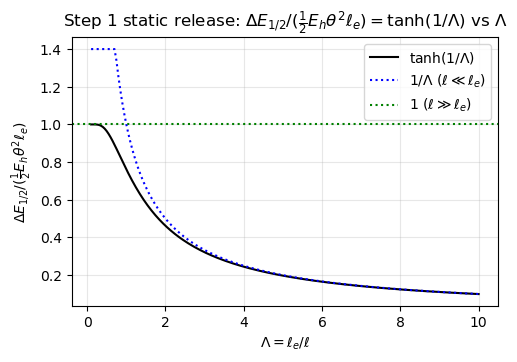

In [12]:
# Verify the released-energy formula against a direct quadrature.
# np.trapz was renamed np.trapezoid in NumPy 2.0; fall back so this runs on either.
trapz = getattr(np, "trapezoid", getattr(np, "trapz"))

theta, ell_e, E_h = 1.0, 1.0, 1.0
for Lam in (5.0, 1.0, 0.2, 0.05):          # Lambda = ell_e/ell
    ell = ell_e / Lam                       # long film <-> small Lambda
    x = np.linspace(0, ell, 20001)
    e_plus = sc.relaxed_strain(x, theta, ell, ell_e)
    u_plus = sc.relaxed_displacement(x, theta, ell, ell_e)
    E_before = 0.5 * E_h * theta**2 * ell                                  # uniform pre-crack strain theta
    E_after  = trapz(0.5 * E_h * e_plus**2 + 0.5 * (E_h / ell_e**2) * u_plus**2, x)  # elastic + foundation (k = E_h/ell_e^2)
    dE_formula = sc.released_energy(theta, ell, ell_e, E_h)
    print(f"Lambda={Lam:5.2f} (ell/ell_e={1/Lam:6.2f}):  dE(quadrature)={E_before - E_after:.6f}"
          f"   dE(tanh formula)={dE_formula:.6f}")

Lam_axis = np.linspace(0.1, 10, 200)
plt.figure(figsize=(5.5, 3.5))
plt.plot(Lam_axis, np.tanh(1.0 / Lam_axis), 'k-', label=r'$\tanh(1/\Lambda)$')
plt.plot(Lam_axis, np.clip(1.0 / Lam_axis, None, 1.4), 'b:', label=r'$1/\Lambda$ ($\ell\ll\ell_e$)')
plt.axhline(1, color='g', ls=':', label=r'$1$ ($\ell\gg\ell_e$)')
plt.xlabel(r'$\Lambda=\ell_e/\ell$'); plt.ylabel(r'$\Delta E_{1/2}/(\frac{1}{2} E_h\theta^2\ell_e)$')
plt.legend(); plt.grid(alpha=0.3)
plt.title(r'Step 1 static release: $\Delta E_{1/2}/(\frac{1}{2} E_h\theta^2\ell_e)=\tanh(1/\Lambda)$ vs $\Lambda$')
plt.show()

## 3. The modal wave picture: which wavelengths carry the energy?

### 3.1 Split off the new equilibrium

The instant the crack opens, the film **has not moved yet**: it is still $u(x,0)=0$ (the pre-crack state), but the *boundary condition* has jumped to traction-free. So the film is out of balance with respect to its new balance $u^+(x)$ from Section 2. Split the motion into the new balance plus a transient:

$$ v(x,t) = u(x,t) - u^+(x). $$

Since $u^+$ is itself a static solution, $v$ obeys the **same homogeneous PDE** $\,m v_{tt}+\eta v_t-E_h v_{xx}+kv=0$, but now with **homogeneous boundary conditions** and a non-zero start:

$$ v_x(0,t)=0,\qquad v(\ell,t)=0,\qquad v(x,0)=-u^+(x),\qquad v_t(x,0)=0. $$

The start follows from $u(x,0)=0$; the velocity is zero because nothing has moved yet. The boundary conditions are the *differences* between the $u$-conditions and the $u^+$-conditions, which is why they become homogeneous: for $t>0$ the free-face condition is $u_x(0,t)=+\theta$ and $u^+_x(0)=+\theta$, so $v_x(0,t)=0$ (PDF eq 11). This is exactly the start set in [`modal_coefficients`](secondary.py) (`v0 = -relaxed_displacement(...)`).

### 3.2 Eigenfunctions and the dispersion relation

The homogeneous conditions (Neumann at $x=0$, Dirichlet at $x=\ell$) pick the cosine basis

$$ \phi_n(x)=\cos(q_n x),\qquad q_n=\frac{(n+\tfrac12)\pi}{\ell},\qquad n=0,1,2,\dots $$

(Check: $\phi_n'(0)=0$ ✓; $\phi_n(\ell)=\cos((n+\tfrac12)\pi)=0$ ✓.) Putting one mode $v=\cos(q_n x)\,e^{i\omega t}$ into the *undamped* PDE ($-m\omega^2+E_h q_n^2+k=0$, divided by $m$) gives the **Winkler dispersion relation**

$$ \boxed{\,\omega_n^2 = \omega_0^2 + c^2 q_n^2\,}\qquad\Big(\text{continuum form } \omega^2=\omega_0^2+c^2q^2\Big), $$

built in [`modal_setup`](secondary.py). **Three consequences:**

1. **Cut-off frequency.** $\omega\ge\omega_0$ always: the substrate blocks any oscillation slower than $\omega_0=c/\ell_e$. (A free bar, $k=0$, has no cut-off.)
2. **Dispersion.** $\omega$ is *not* proportional to $q$, so different wavelengths move at different speeds — a localised pulse spreads out as it travels.
3. **Group velocity.** Energy travels at $v_g=\dfrac{d\omega}{dq}=\dfrac{c^2 q}{\omega}$, which is $<c$ and depends on $q$. Long waves ($q\to0$) hardly move ($v_g\to0$); short waves ($q\to\infty$) approach the free-bar speed $c$.

### 3.3 The modal spectrum is *exactly* a Lorentzian filter

Project the starting mismatch onto the basis (the modes are orthogonal with $\int_0^\ell\cos^2 q_n x\,dx=\ell/2$). Writing $v(x,0)=-u^+(x)=\theta\ell_e\sinh\big((\ell-x)/\ell_e\big)/\cosh(\ell/\ell_e)$,

$$ A_n=a_n(0)=\frac{2}{\ell}\int_0^\ell v(x,0)\,\cos(q_n x)\,dx. $$

This integral has a closed form: integrate by parts twice and use $u^+_{xx}=u^+/\ell_e^2$ (the ODE $u^+$ obeys), which makes the integral reproduce itself so you can solve for it. The result is **not approximate — it is exact** (PDF eq 16):

$$ \boxed{\,a_n(0) = \frac{2\theta\,\ell_e^2/\ell}{\,1+(q_n\ell_e)^2\,}\,}=\frac{2\theta\,\ell_e^2/\ell}{1+\beta_n^2},\qquad \beta_n\equiv q_n\ell_e. $$

This is a **pure positive Lorentzian** in $\beta_n$ — *no* $(-1)^n$ factor — exactly the note's filter $A_n\sim 1/(1+(q_n\ell_e)^2)$ (the code's numerical projection matches it to $\sim10^{-7}$; e.g. $A_0=0.52322$ at $\ell/\ell_e=3$, i.e. $\Lambda=1/3$, the PDF's quoted value). What it means: the first crack does **not** excite all modes equally — it is a low-pass filter with corner at $\beta_n\sim1$. It mostly launches wavelengths $\gtrsim\ell_e$ and strongly suppresses short ones $\beta_n\gg1$ (where $a_n\sim 1/q_n^2$).

> **Why only $1/q_n^2$ decay? Because the crack is a "shock".** The starting data $-u^+(x)$ does **not** match the Neumann condition at the crack: $\partial_x[-u^+]_{x=0}=-\theta\neq0$, while every basis function has zero slope there. This *mismatch between the starting data and the new boundary condition* is exactly what makes the event a stress-release **shock**: a cosine series whose terms all have zero edge-slope can only build a function with non-zero edge-slope by adding up infinitely many modes, and then the spectrum decays slowly ($\sim1/q^2$). In short, suddenly making a free edge injects a *broadband* pulse — just the ingredient needed to (maybe) re-crack the film elsewhere.

### 3.4 The modal energy quota

Each mode carries energy $\propto \omega_n^2 a_n^2$ (kinetic + potential of a unit-mass oscillator of frequency $\omega_n$, amplitude $a_n$). The **normalised energy quota**

$$ Q_n=\frac{\omega_n^2\,a_n^2}{\sum_j \omega_j^2\,a_j^2}=\frac{(1+\beta_n^2)^{-1}}{\sum_j(1+\beta_j^2)^{-1}} $$

(in [`modal_energy_quota`](secondary.py)), plotted against $\beta_n=q_n\ell_e$, shows *which wavelengths carry the released energy*. The $\omega_n^2$ weight partly offsets the $a_n^2\sim1/\beta_n^4$ suppression, so the energy peaks at middling $\beta_n\lesssim1$ — wavelengths near the transfer length $\ell_e$. This answers note questions 2–3 (*which wavelengths carry the energy, and how $\ell_e$ filters the spectrum*).

**In the code cell below:** the markers are the amplitudes/quota from [`modal_coefficients`](secondary.py) (numerical projection), the dashed red line is the exact Lorentzian $1/(1+\beta_n^2)$. The markers are normalised by $|a_0|$, so they trace $(1+\beta_0^2)/(1+\beta_n^2)$ — the same shape, shifted only by the small constant $1+\beta_0^2$; §3.3 shows the *un-normalised* match is exact.

max |numeric - exact Lorentzian| over all modes: 1.3036832171571088e-07


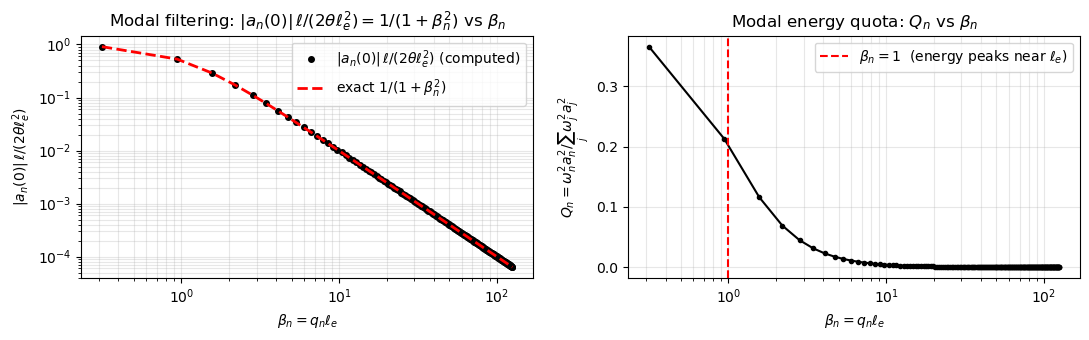

In [13]:
Lam = 0.2                    # Lambda = ell_e/ell  ->  ell = ell_e/Lam = 5 (a long film)
ell = ell_e / Lam
q, omega = sc.modal_setup(ell, ell_e, c=1.0, n_modes=200)
a0 = sc.modal_coefficients(theta, ell, ell_e, q)
Q = sc.modal_energy_quota(omega, a0)
beta = q * ell_e

# Exact closed form of section 3.3:  a_n(0) = -(2 theta ell_e^2/ell) / (1+beta_n^2).
# Compare the *un-normalised* amplitude so the agreement is exact, not just same-shape.
a0_scaled = np.abs(a0) * ell / (2 * theta * ell_e**2)      # -> 1/(1+beta^2)
lorentz   = 1.0 / (1.0 + beta**2)
print("max |numeric - exact Lorentzian| over all modes:", np.max(np.abs(a0_scaled - lorentz)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
ax1.loglog(beta, a0_scaled, 'ko', ms=4, label=r'$|a_n(0)|\,\ell/(2\theta\ell_e^2)$ (computed)')
ax1.loglog(beta, lorentz, 'r--', lw=2, label=r'exact $1/(1+\beta_n^2)$')
ax1.set_xlabel(r'$\beta_n=q_n\ell_e$'); ax1.set_ylabel(r'$|a_n(0)|\,\ell/(2\theta\ell_e^2)$')
ax1.legend(); ax1.grid(alpha=0.3, which='both')
ax1.set_title(r'Modal filtering: $|a_n(0)|\,\ell/(2\theta\ell_e^2)=1/(1+\beta_n^2)$ vs $\beta_n$')
ax2.semilogx(beta, Q, 'ko-', ms=3)
ax2.axvline(1, color='r', ls='--', label=r'$\beta_n=1$  (energy peaks near $\ell_e$)')
ax2.set_xlabel(r'$\beta_n=q_n\ell_e$'); ax2.set_ylabel(r'$Q_n=\omega_n^2 a_n^2/\sum_j\omega_j^2 a_j^2$')
ax2.legend(); ax2.grid(alpha=0.3, which='both')
ax2.set_title(r'Modal energy quota: $Q_n$ vs $\beta_n$')
plt.tight_layout(); plt.show()

## 4. Reflection, superposition, and damping

### 4.1 The round-trip time of the released packet

Most of the released energy is in modes with $\beta_n=q_n\ell_e\sim\mathcal O(1)$ (Section 3.4), so take the **representative component** $q\sim 1/\ell_e$ as a stand-in for the pulse. Its frequency and group velocity come from the dispersion relation (recall $\omega_0=c/\ell_e$):

$$ \omega=\sqrt{\omega_0^2+c^2q^2}\;\Big|_{q=1/\ell_e}=\sqrt{2}\,\omega_0,\qquad v_g=\frac{c^2 q}{\omega}\Big|_{q=1/\ell_e}=\frac{c^2/\ell_e}{\sqrt2\,c/\ell_e}=\frac{c}{\sqrt2}. $$

The pulse leaves the crack ($x=0$), travels to the far end ($x=\ell$), reflects, and comes back — a distance $2\ell$ at speed $v_g$. So the **round-trip time** is

$$ \boxed{\,\tau_{rt}\sim\frac{2\ell}{v_g}\sim 2\sqrt2\,\frac{\ell}{c}\,}, $$

exactly the `tau_rt = 2*sqrt(2)*ell/c` in [`run_problem`](secondary.py). This is the natural clock of the problem: a second crack, if it happens, happens *because the wave returns and overlaps itself*, so we measure damping against one round trip.

### 4.2 The damping number $\Gamma$

Damping makes each mode decay like $e^{-\gamma t}$ (Section 4.3), so over one round trip the amplitude drops by $e^{-\gamma\tau_{rt}}=e^{-\Gamma}$. The single **damping number**

$$ \boxed{\,\Gamma=\gamma\,\tau_{rt}\,} $$

decides the fate of the pulse (in the code, `gamma_bar = Gamma / tau_rt` recovers $\gamma$ from a chosen $\Gamma$):

| regime | meaning |
|---|---|
| $\Gamma\ll1$ | waves survive many reflections — they **refocus** and may re-crack the film |
| $\Gamma\sim1$ | the pulse is noticeably weakened within one round trip |
| $\Gamma\gg1$ | the wave dies **before** it returns — no second crack |

### 4.3 Each mode is a damped oscillator

Put $v=\sum_n a_n(t)\cos(q_n x)$ into the full PDE. Orthogonality of the $\cos(q_n x)$ splits the modes into independent damped oscillators:

$$ \ddot a_n + 2\gamma\,\dot a_n + \omega_n^2\,a_n = 0 $$

(divide $m v_{tt}+\eta v_t-E_h v_{xx}+kv=0$ by $m$, use $v_{xx}\to-q_n^2$, and $E_h/m=c^2$, $k/m=\omega_0^2$ so that $c^2 q_n^2+\omega_0^2=\omega_n^2$). With the **start from rest** $a_n(0)$ from §3.3 and $\dot a_n(0)=0$, the under-damped solution is (PDF eq 18)

$$ \boxed{\,a_n(t)=a_n(0)\,e^{-\gamma t}\Big(\cos\Omega_n t+\frac{\gamma}{\Omega_n}\sin\Omega_n t\Big)\,},\qquad \Omega_n=\sqrt{\omega_n^2-\gamma^2}, $$

in [`modal_evolution`](secondary.py). The code takes $\Omega_n$ as a **complex** square root, so the *same* formula still works in the over-damped case $\gamma>\omega_n$ (then $\cos,\sin\to\cosh,\sinh$ and the mode decays without oscillating) — only the real part is kept. Each mode keeps its *own* frequency $\omega_n$ but shares the *same* decay rate $\gamma$: damping is the same across wavelengths.

### 4.4 Reconstructing the dynamic strain

Add up the modes to get the transient field, then differentiate for the strain. With $v_x=\sum_n a_n(t)\,\partial_x\cos(q_n x)=-\sum_n q_n a_n(t)\sin(q_n x)$ and $e=e^++v_x$ (§1.2, §3.1):

$$ v(x,t)=\sum_n a_n(t)\cos(q_n x),\qquad \boxed{\,e(x,t)=\underbrace{e^+(x)}_{\text{relaxed (static)}}\;-\;\underbrace{\sum_n q_n a_n(t)\sin(q_n x)}_{\text{travelling transient}}\,}, $$

exactly [`strain_field`](secondary.py) (PDF eq 20). **Check at $t=0$:** the $a_n(0)$ are the cosine coefficients of $-u^+$, so $v_x(x,0)=-u^+_x(x)$ and $e(x,0)=e^+(x)-u^+_x(x)=(u^+_x-\theta)-u^+_x=-\theta$ — the *uniform* pre-stress $e_0=-\theta$ everywhere, as it must be (nothing has moved yet, up to mode truncation). At the crack face $x=0$, $\sin(q_n\cdot 0)=0\Rightarrow v_x(0,t)=0$, so $e(0,t)=e^+(0)=0$ stays traction-free for all $t$. As $t$ grows the $\sin(q_n x)$ terms travel, reflect, and overlap; Section 5 asks whether their sum can briefly push $|e|$ past $e_{crit}$ somewhere away from the first crack.

Putting §4.1–§4.4 together: a second crack hinges on the competition between $\ell_e$, $\ell$, $c$, $\eta$ and the damage length $\ell_d$ — which collapse into just $(\Lambda,\Gamma,\hat\ell)$.

## 5. The damage criterion: when does a second crack nucleate?

Now we need a *material* statement: given the dynamic strain $e(x,t)$ from Section 4, when is the film locally damaged enough to break again? We reuse the **nucleation threshold of the gradient-damage (phase-field) model** used elsewhere in this repository (PDF Section 7).

### 5.1 The damage energy density

Add a damage variable $\alpha\in[0,1]$ ($0$ = intact, $1$ = fully broken). The 1D energy density is

$$ \psi(e,\alpha)=\underbrace{\tfrac12 E_h\,a(\alpha)\,e^2}_{\text{(degraded) elastic}} + \underbrace{\frac{G_c}{\ell_d}\,w(\alpha)}_{\text{local fracture}} + \underbrace{G_c\,\ell_d\,|\alpha_x|^2}_{\text{gradient}},\qquad e=u_x-\theta, $$

(the same $e=u_x-\theta$ as §1.2, so the strain that enters the criterion is exactly the dynamic strain of Section 4), with the standard sign assumptions

$$ a(0)=1,\quad a'(0)<0\ \ (\text{stiffness drops with damage}),\qquad w(0)=0,\quad w'(0)\ge0\ \ (\text{damage costs energy}). $$

Here $a(\alpha)$ is the **stiffness degradation function** (the note's $a$ is the code's `g`, e.g. $g(\alpha)=(1-\alpha)^2$ so $a'(0)=-2$), $w(\alpha)$ is the **local dissipation potential**, $G_c$ the fracture toughness, and $\ell_d$ the **damage length** (the note's $\ell_d$ — *not* the half-specimen length $\ell$). In the code $\ell_d$ is set by the third control parameter through $\ell_d=\hat\ell\,\ell$ (`l_hat` $\times$ `ell`); a larger $\hat\ell$ means a coarser, tougher damage band.

### 5.2 First-order nucleation condition

From the intact state $\alpha=0$, damage can only *grow* ($\dot\alpha\ge0$). It starts to grow when pushing the energy *downhill* in the $+\alpha$ direction is no longer penalised, i.e. when the first variation vanishes:

$$ \partial_\alpha\psi(e,0)=\tfrac12 E_h\,a'(0)\,e^2+\frac{G_c}{\ell_d}\,w'(0)=0. $$

Since $a'(0)<0$ the elastic term is *destabilising* (more strain $\Rightarrow$ stronger push to damage) while the fracture term is *stabilising*. Solving for the strain gives the **algebraic nucleation threshold** (PDF eq 21)

$$ \boxed{\,e^2\ \ge\ \varepsilon_{crit}^2:=\frac{2\,G_c\,w'(0)}{E_h\,\ell_d\,|a'(0)|}\,},\qquad N_{crit}=E_h\,\varepsilon_{crit}. $$

This is exactly [`critical_strain`](../tools/solvers.py), which gets $w'(0)$ and $a'(0)$ by a finite difference on the model lambdas. (Note the threshold depends only on $e^2$, so it is the same in either sign convention — the only thing the §1.2 sign fixes is the *sign* of the dynamic $e$ we compare against it, not the threshold.) **Key point for the third axis:** $\varepsilon_{crit}\propto1/\sqrt{\ell_d}=1/\sqrt{\hat\ell\,\ell}$, so at fixed geometry a *smaller* $\hat\ell$ raises $\varepsilon_{crit}$ (a finer damage band is harder to trigger) — this is how $\hat\ell$ tunes $\varepsilon_{crit}/\theta$.

### 5.3 AT1 vs AT2 — why the model choice matters ⚠️

The two standard phase-field models differ exactly in $w'(0)$:

| model | $w(\alpha)$ | $w'(0)$ | $\varepsilon_{crit}$ (with $G_c{=}E_h{=}\ell_d{=}1$, $a'(0){=}-2$) | sub-critical elastic phase? |
|---|---|---|---|---|
| **AT1** | $\alpha$ | $1$ | $\varepsilon_{crit}=\sqrt{G_c/(E_h\ell_d)}=1$ | **yes** — finite threshold |
| **AT2** | $\alpha^2$ | $0$ | $\varepsilon_{crit}=0$ | **no** — damages at any strain |

So **only AT1 gives a finite threshold** (the PDF's AT1 example: $a=(1-\alpha)^2$, $w=\alpha$, $\varepsilon_{crit}=\sqrt{G_c/(E_h\ell_d)}$). AT2 has $\varepsilon_{crit}=0$: damage grows from zero strain, so "did the wave pass a threshold?" makes no sense. **This study needs AT1** (the code cell below confirms both values). With $\theta=1$ and $\ell_d=1$ the AT1 threshold $\varepsilon_{crit}=1$ would sit the film exactly at the static threshold, so we push $\varepsilon_{crit}$ a little above $\theta$ — either by an explicit `e_crit` or, in the sweep of Section 7, by lowering $\hat\ell$ so that $\varepsilon_{crit}=1/\sqrt{\hat\ell\,\ell}>\theta$.

### 5.4 The secondary-cracking test

A second crack fires iff the **dynamic** strain reaches the threshold somewhere away from the already-relaxed first crack (PDF Criterion 1):

$$ |e(x,t)|\ \ge\ \varepsilon_{crit}\quad\text{for some }t>0\text{ and some }x\gtrsim\text{(a few }\ell_e\text{ from the crack)}. $$

The excluded zone (a few $\ell_e$ around $x=0$, where stress is already relaxed and the first damage band sits) is handled by [`effective_exclusion`](secondary.py)/[`detect_secondary_trigger`](secondary.py). The **trigger margin** is

$$ \mathcal R_{crack}=\max_{x,t}\frac{|e(x,t)|}{\varepsilon_{crit}},\qquad \mathcal R_{crack}\ge1\ \Longleftrightarrow\ \text{secondary crack},\qquad \mathcal R_{crack}=\mathcal R_{crack}(\Lambda,\Gamma,\hat\ell). $$

**The window that matters.** The film carries a pre-stress of magnitude $|e_0|=\theta$, so a film with $\varepsilon_{crit}<\theta$ would already have cracked statically — not interesting. The interesting range is

$$ 1<\frac{\varepsilon_{crit}}{\theta}\lesssim 2 : $$

the film is *just* below threshold statically, and the only way to break it again is a **dynamic overshoot** — the reflected, overlapping wave must briefly push $|e|$ above $\varepsilon_{crit}$ before damping kills it. Since $\varepsilon_{crit}/\theta=1/\sqrt{\hat\ell\,\ell}$ (with $\theta=1$, $\ell=\ell_e/\Lambda$), this window is exactly what the third control parameter $\hat\ell$ selects — small $\hat\ell$ pushes $\varepsilon_{crit}$ up into the interesting range.

In [14]:
print('e_crit (AT1):', critical_strain('AT1', Gc=1.0, E_h=1.0, ell_d=1.0))
print('e_crit (AT2):', critical_strain('AT2', Gc=1.0, E_h=1.0, ell_d=1.0), ' (no elastic phase)')

e_crit (AT1): 1.000000000263178
e_crit (AT2): 0.00010000000002631779  (no elastic phase)


## 6. Putting it together: one run

[`run_problem`](secondary.py) chains Steps 1–4 for one $(\Lambda,\Gamma,\hat\ell)$ triple: it builds the modes (§3), evolves them with damping (§4), rebuilds the space–time strain $e(x,t)$ (§4.4), and applies the trigger test (§5.4). The threshold is either derived from $\hat\ell$ (via $\ell_d=\hat\ell\,\ell$) or, as in the two runs below, pinned with an explicit `e_crit` so the geometry/damping contrast is clean. Then it calls `tools.plotting.plot_secondary_run` for a six-panel diagnostic that follows the note's list of questions in order:

1. **static release** — $\Delta E_{1/2}(\Lambda)$ (Step 1);
2. **modal energy quota** $Q_n$ vs $\beta_n$ (Step 2);
3. the **space–time strain map** $e(x,t)$ with the $|e|=e_{crit}$ contour on top;
4. the **overshoot envelope** $\max_t|e(x,t)|$ — *where* along the film a second crack would show up;
5. the **threshold-crossing history** $\max_x|e(x,t)|$ vs $t$, against the round-trips and the $e^{-\gamma t}$ decay envelope — *when* it would show up;
6. the **released-energy curve** for reference.

**Where and when the overshoot shows up.** It helps to know *what* the strain map shows before reading it: the biggest overshoot sits near the **far / symmetry end $x=\ell$** and appears **within the first half round-trip** ($t\sim\tfrac12\tau_{rt}$), not after many reflections. The reason: $x=\ell$ carries the condition $v(\ell,t)=0$ — a *strain antinode* where the released pulse piles up. So in 1D the "refocusing" is mostly the released shock arriving at the symmetry plane; later reflections only add to it. That is also why damping matters: it has only a fraction of a round-trip to act before that first pile-up.

The two runs below compare the two damping regimes of §4.2 at fixed geometry $\Lambda=\ell_e/\ell=0.2$ (i.e. $\ell=5\ell_e$, a long film) and a sub-critical threshold $e_{crit}=1.3>\theta=1$:

- **Weak damping** ($\Gamma=0.2$): the shock reaches the symmetry end almost undamped and the strain briefly **overshoots** $e_{crit}$ → second crack (`trigger` is not `None`).
- **Strong damping** ($\Gamma=3.0$): the pulse is weakened enough on the way to $x=\ell$ that the strain never reaches $e_{crit}$ → no second crack.

> **Why $e_{crit}=1.3$ and not $1.1$ here?** At $\Lambda=0.2$ ($\ell=5\ell_e$) the *undamped* overshoot is large, $\max|e|/\theta\approx2.2$ (run it: `trigger_map` margin at $\Gamma=0$). A threshold very close to $\theta$ (e.g. $1.1$) then cracks for *almost any* damping — even $\Gamma=3$ still overshoots — so it makes a poor illustration. Raising $e_{crit}$ to $1.3$ puts the weak/strong boundary at a moderate $\Gamma$, giving the clean contrast below. This sensitivity to $e_{crit}/\theta$ is exactly the third axis of the regime map ($\hat\ell$, Section 7).

Watch the printed `secondary crack` / `no secondary crack` lines and compare the panel-3 strain maps of the two runs.

In [15]:
# Same geometry (Lambda=0.2, i.e. ell=5*ell_e) and threshold (e_crit=1.3 > theta=1), contrasting damping.
# Weak damping: the released shock overshoots e_crit -> secondary crack.
res_weak = sc.run_problem({'Lambda_bar': 0.2, 'Gamma': 0.2, 'e_crit': 1.3})

# Strong damping: the packet is killed before it overshoots -> no secondary crack.
res_strong = sc.run_problem({'Lambda_bar': 0.2, 'Gamma': 3.0, 'e_crit': 1.3})

print("\nweak  Gamma=0.2 :", "secondary crack" if res_weak['trigger'] else "no secondary crack")
print("strong Gamma=3.0 :", "secondary crack" if res_strong['trigger'] else "no secondary crack")


[SECONDARY | semi-analytic]  Lambda_bar=0.2, Gamma=0.2, l_hat=0.1  ->  ell=5, ell_d=0.5, tau_rt=14.1, gamma=0.0141, e_crit/theta=1.3, n_modes=200
  SECONDARY CRACK triggered at t/tau_rt=0.395, x/ell_e=4.39 (|e|/e_crit=1.004)
  saved /home/sajjad/Internship-2026/output/png/secondary_run_Lam0.2_Gam0.2_lhat0.1_ecrit1.3_AT1_nm200_nrt4.png
        /home/sajjad/Internship-2026/output/pdf/secondary_run_Lam0.2_Gam0.2_lhat0.1_ecrit1.3_AT1_nm200_nrt4.pdf

[SECONDARY | semi-analytic]  Lambda_bar=0.2, Gamma=3, l_hat=0.1  ->  ell=5, ell_d=0.5, tau_rt=14.1, gamma=0.212, e_crit/theta=1.3, n_modes=200
  no secondary crack (wave damped below threshold)
  saved /home/sajjad/Internship-2026/output/png/secondary_run_Lam0.2_Gam3_lhat0.1_ecrit1.3_AT1_nm200_nrt4.png
        /home/sajjad/Internship-2026/output/pdf/secondary_run_Lam0.2_Gam3_lhat0.1_ecrit1.3_AT1_nm200_nrt4.pdf

weak  Gamma=0.2 : secondary crack
strong Gamma=3.0 : no secondary crack


## 7. Regime maps — the criterion the note asks for

Steps 1–5 give a yes/no answer for one parameter set; the *phase diagram* comes from sweeping the control numbers. [`trigger_map`](secondary.py) runs `run_problem` over the $(\Lambda,\Gamma,\hat\ell)$ cube and records the **trigger margin**

$$ \mathcal R(\Lambda,\Gamma,\hat\ell)=\max_{x,t}\frac{|e(x,t)|}{e_{crit}},\qquad e_{crit}=\frac{1}{\sqrt{\hat\ell\,\ell}}\ \ (\text{AT1},\,G_c{=}E_h{=}1). $$

For **each** value of $\hat\ell$ it sweeps the $(\Lambda,\Gamma)$ plane and draws a heat-map (via `tools.plotting.plot_secondary_regime_map`), whose **level-1 contour $\mathcal R=1$ is the secondary-cracking boundary**:

- $\mathcal R<1$ — **no second crack** (smooth relaxation; the wave never reaches threshold again);
- $\mathcal R\approx1$ — **near threshold** (a second crack is marginal, sensitive to parameters);
- $\mathcal R>1$ — **likely second crack** (and, repeating, a possible fragmentation cascade).

This is exactly the short answer the note wants: one inequality $\mathcal R(\Lambda,\Gamma,\hat\ell)\ge1$ organising the change from a single crack to fragmentation. Reading a map, the boundary moves the intuitive way — **more damping** (larger $\Gamma$) suppresses second cracks, while **geometry** $\Lambda=\ell_e/\ell$ sets both how much energy is released (Step 1) and how the round-trip time scales (Step 4); the **damage length** $\hat\ell$ shifts the whole boundary through $e_{crit}\propto1/\sqrt{\hat\ell}$.

The sweep below produces **ten figures**: one $(\Lambda,\Gamma)$ regime map for **each of the nine $\hat\ell$ values** (file name carries $\hat\ell$ so they do not overwrite), plus a single **paper-style summary** (`plot_secondary_regime_summary`) that overlays every $\mathcal R=1$ boundary in one $(\Lambda,\Gamma)$ plane, coloured by $\hat\ell$. Note we do **not** pass an explicit `e_crit` here — letting $\hat\ell$ set the threshold is the whole point of the third axis. It uses the coarse default resolution (`n_modes=120, n_x=200, n_t=400`) that `trigger_map` sets internally for speed; nine full planes still take a little while.

In [16]:
# Sweep the (Lambda, Gamma) plane for nine damage-length ratios l_hat.
# Lambda = ell_e/ell in [0.1, 2] spans long films (small Lambda) to short ones;
# e_crit is derived from l_hat (via ell_d = l_hat*ell), so DON'T pin e_crit here.
# -> nine (Lambda, Gamma) regime maps (one per l_hat) + one summary of R=1 boundaries.
sweep = sc.trigger_map(Lambda_bars=np.linspace(0.1, 2.0, 12),
                       Gammas=np.linspace(0.0, 2.0, 9),
                       l_hats=np.geomspace(0.02, 0.5, 9))

  [trigger_map] l_hat=0.02 done (1/9)
  [trigger_map] l_hat=0.029907 done (2/9)
  [trigger_map] l_hat=0.0447214 done (3/9)
  [trigger_map] l_hat=0.066874 done (4/9)
  [trigger_map] l_hat=0.1 done (5/9)
  [trigger_map] l_hat=0.149535 done (6/9)
  [trigger_map] l_hat=0.223607 done (7/9)
  [trigger_map] l_hat=0.33437 done (8/9)
  [trigger_map] l_hat=0.5 done (9/9)
  saved /home/sajjad/Internship-2026/output/png/secondary_map_lhat0.02_Lam0.1-2_Gam0-2_AT1_nm120.png
        /home/sajjad/Internship-2026/output/pdf/secondary_map_lhat0.02_Lam0.1-2_Gam0-2_AT1_nm120.pdf
  saved /home/sajjad/Internship-2026/output/png/secondary_map_lhat0.029907_Lam0.1-2_Gam0-2_AT1_nm120.png
        /home/sajjad/Internship-2026/output/pdf/secondary_map_lhat0.029907_Lam0.1-2_Gam0-2_AT1_nm120.pdf
  saved /home/sajjad/Internship-2026/output/png/secondary_map_lhat0.0447214_Lam0.1-2_Gam0-2_AT1_nm120.png
        /home/sajjad/Internship-2026/output/pdf/secondary_map_lhat0.0447214_Lam0.1-2_Gam0-2_AT1_nm120.pdf
  saved /hom

## 8. Validating the regime map: sampling points and *watching* the secondary crack

The maps in Section 7 compress the whole study into a single number per parameter set — the trigger margin $\mathcal R(\Lambda,\Gamma,\hat\ell)=\max_{x,t}|e(x,t)|/e_{crit}$ — and a single line, the $\mathcal R=1$ boundary. That is convenient, but it hides *what actually happens* to the film. This section **opens the black box**: we pick sample points on the map and, at each one, redo the full space–time computation and **look at the strain field** to check that the classification is physically real — that $\mathcal R\ge1$ really corresponds to the dynamic strain overshooting the cracking threshold *somewhere away from the first crack* (a genuine second-crack site), and that $\mathcal R<1$ really means the wave never gets there.

**The sampling design (as requested).** On one clean $(\Lambda,\Gamma)$ plane (fixed threshold $e_{crit}=1.3>\theta=1$, exactly the Section 6 setting) we take:

- **three points along a vertical line** (fixed geometry $\Lambda$, increasing damping $\Gamma$), and
- **three points along a horizontal line** (fixed damping $\Gamma$, increasing $\Lambda=\ell_e/\ell$, i.e. shorter films),

and in each triple we deliberately choose **one point deep in the "secondary-crack likely" region** ($\mathcal R\gg1$), **one on the boundary** ($\mathcal R\approx1$), and **one in the "unlikely" region** ($\mathcal R\ll1$). The two diagnostics we read at each point are exactly the two the note suggests:

1. the **crack profile** — the overshoot envelope $\displaystyle E(x)=\max_t|e(x,t)|$ along the film, with the threshold $e_{crit}$ drawn on top. Wherever the curve pokes above $e_{crit}$ *outside the grey exclusion zone*, that is where a secondary crack would nucleate;
2. the **space–time strain map** $e(x,t)$ — so we can *watch* the released pulse travel to the symmetry end and either overshoot or die.

If the map is trustworthy, the profile at every "likely" point must cross $e_{crit}$ away from the crack, the "unlikely" points must stay below it, and the "boundary" points must just graze it.

vertical  line  Lambda = 0.2
   likely  : Gamma=0.00  R=1.99  -> SECONDARY
   boundary: Gamma=1.50  R=1.01  -> SECONDARY
   unlikely: Gamma=3.00  R=0.88  -> none
horizontal line Gamma  = 0.6
   likely  : Lambda=0.29  R=1.54  -> SECONDARY
   boundary: Lambda=1.05  R=0.99  -> none
   unlikely: Lambda=1.24  R=0.88  -> none
saved /home/sajjad/Internship-2026/output/secondary_validation_map.png


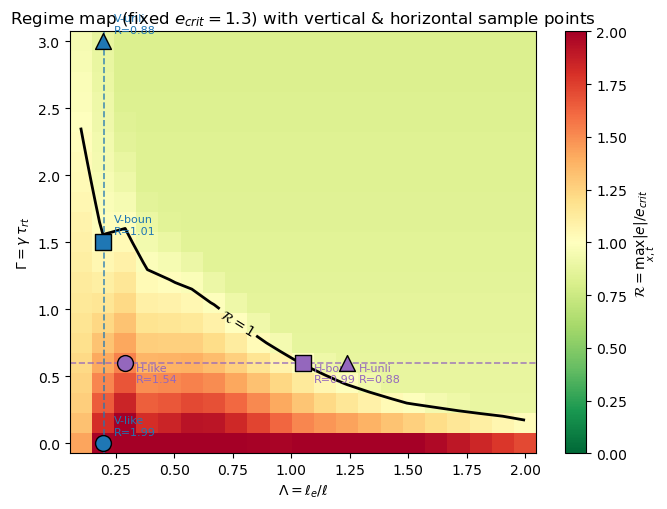

In [17]:
# ---------------------------------------------------------------------------
# 8a. Build one clean R(Lambda, Gamma) map (fixed e_crit) and choose the six
#     sample points: a vertical triple (fixed Lambda) and a horizontal triple
#     (fixed Gamma), each spanning likely / boundary / unlikely.
# ---------------------------------------------------------------------------
OUT = ROOT / "output"

e_crit_val = 1.3                                   # same threshold as section 6
Lam_axis = np.linspace(0.1, 2.0, 21)               # geometry Lambda = ell_e/ell
Gam_axis = np.linspace(0.0, 3.0, 21)               # damping number Gamma

# coarse resolution for the dense field (as trigger_map does) -> fast
_field_pars = {"e_crit": e_crit_val, "n_modes": 120, "n_x": 200, "n_t": 400}

def margin(Lam, Gam, pars=_field_pars):
    r = sc.run_problem({**pars, "Lambda_bar": float(Lam), "Gamma": float(Gam)},
                       plot=False, verbose=False)
    xm = r["x"] >= r["x_excl"]
    return np.abs(r["e_xt"][xm, :]).max() / r["e_crit"]

R = np.array([[margin(L, G) for L in Lam_axis] for G in Gam_axis])   # R[gi, li]

# --- choose the lines and the three points on each ---------------------------
Lam_v = 0.20                       # vertical line: long film (strong overshoot)
Gam_h = 0.60                       # horizontal line: moderate damping
iv = int(np.argmin(np.abs(Lam_axis - Lam_v)))
jh = int(np.argmin(np.abs(Gam_axis - Gam_h)))

def triple(vals):
    """Return indices (likely=max R, boundary=|R-1| min, unlikely=min R)."""
    return dict(likely=int(np.argmax(vals)),
                boundary=int(np.argmin(np.abs(vals - 1.0))),
                unlikely=int(np.argmin(vals)))

col = R[:, iv]                      # R vs Gamma at fixed Lambda_v (vertical)
row = R[jh, :]                      # R vs Lambda at fixed Gamma_h (horizontal)
tv, th = triple(col), triple(row)

pts_vert = [(Lam_axis[iv], Gam_axis[tv[k]], col[tv[k]], k) for k in
            ("likely", "boundary", "unlikely")]
pts_horiz = [(Lam_axis[th[k]], Gam_axis[jh], row[th[k]], k) for k in
             ("likely", "boundary", "unlikely")]

print("vertical  line  Lambda =", round(Lam_v, 3))
for L, G, r, k in pts_vert:
    print(f"   {k:8s}: Gamma={G:4.2f}  R={r:4.2f}  -> {'SECONDARY' if r>=1 else 'none'}")
print("horizontal line Gamma  =", round(Gam_h, 3))
for L, G, r, k in pts_horiz:
    print(f"   {k:8s}: Lambda={L:4.2f}  R={r:4.2f}  -> {'SECONDARY' if r>=1 else 'none'}")

# --- draw the map with the two lines and the six points ----------------------
fig, ax = plt.subplots(figsize=(6.8, 5.2))
pc = ax.pcolormesh(Lam_axis, Gam_axis, R, shading="auto", cmap="RdYlGn_r",
                   vmin=0.0, vmax=2.0)
cs = ax.contour(Lam_axis, Gam_axis, R, levels=[1.0], colors="k", linewidths=2)
ax.clabel(cs, fmt=r"$\mathcal{R}=1$", fontsize=10)
fig.colorbar(pc, ax=ax, label=r"$\mathcal{R}=\max_{x,t}|e|/e_{crit}$")
ax.axvline(Lam_v, color="tab:blue", ls="--", lw=1.2, alpha=0.8)
ax.axhline(Gam_h, color="tab:purple", ls="--", lw=1.2, alpha=0.8)
mk = {"likely": "o", "boundary": "s", "unlikely": "^"}
for L, G, r, k in pts_vert:
    ax.scatter([L], [G], marker=mk[k], s=130, edgecolor="k", facecolor="tab:blue", zorder=5)
    ax.annotate(f"V-{k[:4]}\nR={r:.2f}", (L, G), textcoords="offset points",
                xytext=(8, 6), fontsize=8, color="tab:blue")
for L, G, r, k in pts_horiz:
    ax.scatter([L], [G], marker=mk[k], s=130, edgecolor="k", facecolor="tab:purple", zorder=5)
    ax.annotate(f"H-{k[:4]}\nR={r:.2f}", (L, G), textcoords="offset points",
                xytext=(8, -14), fontsize=8, color="tab:purple")
ax.set_xlabel(r"$\Lambda=\ell_e/\ell$"); ax.set_ylabel(r"$\Gamma=\gamma\,\tau_{rt}$")
ax.set_title(r"Regime map (fixed $e_{crit}=%.1f$) with vertical & horizontal sample points" % e_crit_val)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(OUT / f"secondary_validation_map.{ext}", dpi=150, bbox_inches="tight")
print("saved", OUT / "secondary_validation_map.png")
plt.show()

saved /home/sajjad/Internship-2026/output/secondary_validation_profiles.png


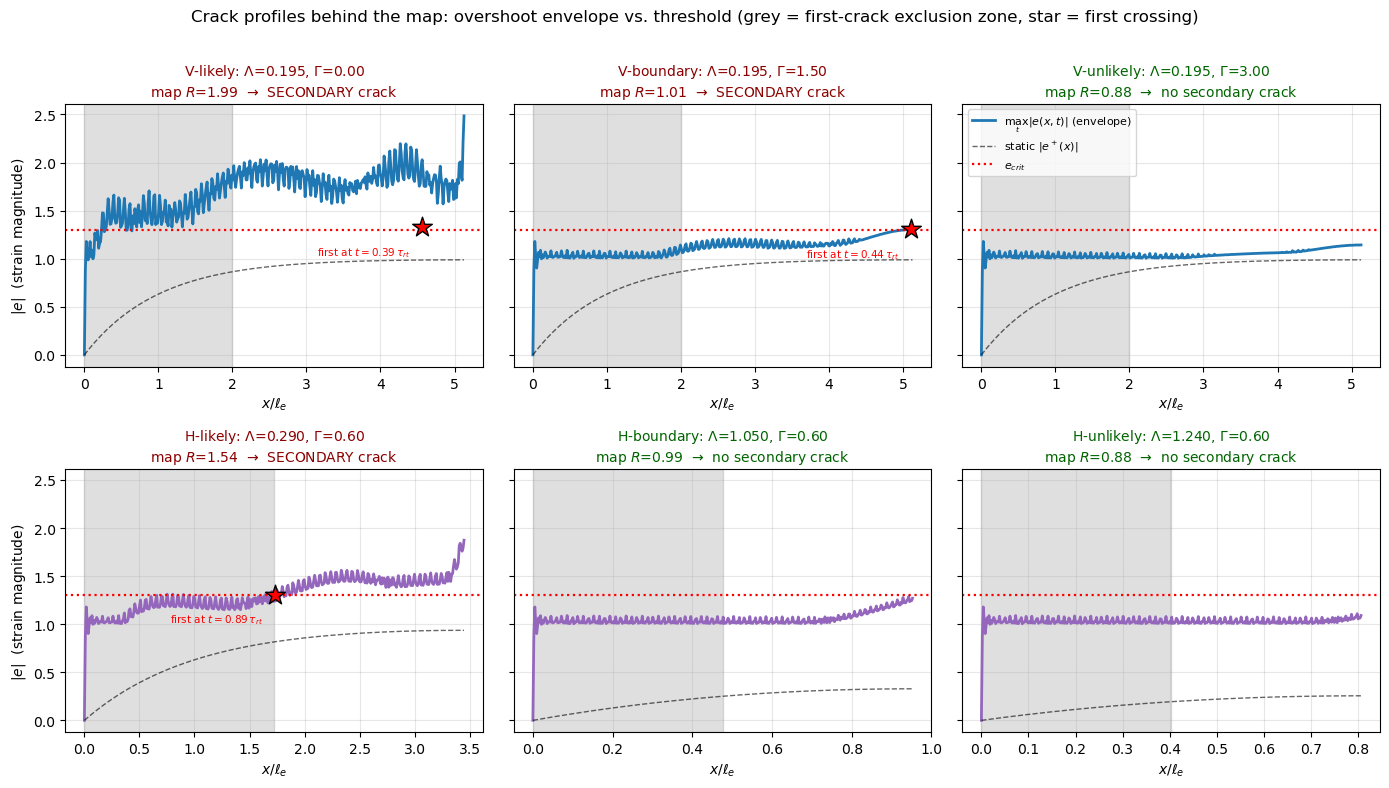

In [18]:
# ---------------------------------------------------------------------------
# 8b. Crack profiles at the six points: the overshoot envelope max_t |e(x,t)|
#     with the threshold e_crit. A secondary crack forms wherever the envelope
#     rises above e_crit OUTSIDE the grey exclusion zone (the first crack).
#     Top row  = vertical triple (fixed Lambda, increasing damping).
#     Bottom row = horizontal triple (fixed Gamma, increasing Lambda).
#
#     NOTE on the star: it marks the FIRST space-time crossing of e_crit
#     (from `detect_secondary_trigger`), so its height is |e| at that first
#     instant -- essentially e_crit itself. The blue curve is the maximum over
#     ALL time, so it is normally HIGHER than the star. Envelope = "the worst
#     it ever gets"; star = "where and when it first breaks".
# ---------------------------------------------------------------------------
def full_run(Lam, Gam):
    return sc.run_problem({"Lambda_bar": float(Lam), "Gamma": float(Gam),
                           "e_crit": e_crit_val}, plot=False, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
for row_i, (pts, tag, color) in enumerate(
        [(pts_vert, "V", "tab:blue"), (pts_horiz, "H", "tab:purple")]):
    for col_i, (L, G, r, k) in enumerate(pts):
        ax = axes[row_i, col_i]
        res = full_run(L, G)
        x, ell_e_ = res["x"], res["parameters"]["ell_e"]
        env = np.abs(res["e_xt"]).max(axis=1)          # max_t |e(x,t)|  (crack profile)
        xh = x / ell_e_
        ax.plot(xh, env, color=color, lw=2, label=r"$\max_t|e(x,t)|$ (envelope)")
        ax.plot(xh, np.abs(res["e_plus"]), "k--", lw=1, alpha=0.6,
                label=r"static $|e^+(x)|$")
        ax.axhline(e_crit_val, color="red", ls=":", lw=1.6, label=r"$e_{crit}$")
        ax.axvspan(0, res["x_excl"] / ell_e_, color="grey", alpha=0.25)  # excluded (1st crack)
        trig = res["trigger"]
        if trig:                                        # first crossing = 2nd-crack birth
            ax.scatter([trig["x"] / ell_e_], [trig["e"]], marker="*", s=220,
                       color="red", edgecolor="k", zorder=6,
                       label=r"first crossing of $e_{crit}$ (in TIME)")
            # the star is a TIME marker, so print the time next to it -- otherwise
            # readers expect it at the left-most crossing of the envelope.
            ax.annotate(rf"first at $t={trig['t'] / res['tau_rt']:.2f}\,\tau_{{rt}}$",
                        (trig["x"] / ell_e_, trig["e"]), textcoords="offset points",
                        xytext=(-8, -20), fontsize=7.5, color="red", ha="right")
        verdict = "SECONDARY crack" if trig else "no secondary crack"
        ax.set_title(f"{tag}-{k}: $\\Lambda$={L:.3f}, $\\Gamma$={G:.2f}\n"
                     f"map $R$={r:.2f}  →  {verdict}",
                     fontsize=10, color=("darkred" if trig else "darkgreen"))
        ax.set_xlabel(r"$x/\ell_e$"); ax.grid(alpha=0.3)
        if col_i == 0:
            ax.set_ylabel(r"$|e|$  (strain magnitude)")
        if row_i == 0 and col_i == 2:
            ax.legend(fontsize=8, loc="upper left")
fig.suptitle("Crack profiles behind the map: overshoot envelope vs. threshold "
             "(grey = first-crack exclusion zone, star = first crossing)",
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.97])
for ext in ("png", "pdf"):
    fig.savefig(OUT / f"secondary_validation_profiles.{ext}", dpi=150, bbox_inches="tight")
print("saved", OUT / "secondary_validation_profiles.png")
plt.show()

saved /home/sajjad/Internship-2026/output/secondary_validation_spacetime.png | common colour scale 0 .. 2.485


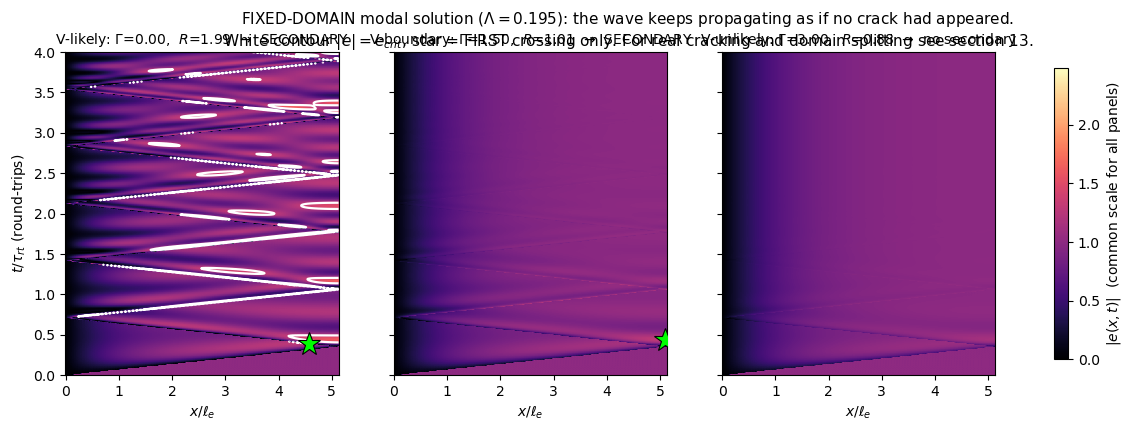

In [19]:
# ---------------------------------------------------------------------------
# 8c. Watch the released pulse: space-time strain |e(x,t)| for the vertical
#     triple. The white contour is |e| = e_crit; the green star is the FIRST
#     space-time point outside the exclusion zone that reaches the threshold
#     (= where and when the secondary crack is born).
#
#     Two plotting rules that matter for a quantitative heat-map:
#       * all three panels share ONE colour scale, so they are directly
#         comparable and the single colorbar is valid for all of them;
#       * the exclusion zone is marked with a dashed LINE, not a translucent
#         overlay -- a colour wash would make the same |e| appear as two
#         different colours on the two sides of the boundary.
# ---------------------------------------------------------------------------
runs = [(L, G, r, k, full_run(L, G)) for (L, G, r, k) in pts_vert]
vmax = max(np.abs(res["e_xt"]).max() for *_, res in runs)      # COMMON colour scale

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (L, G, r, k, res) in zip(axes, runs):
    x, t, ell_e_ = res["x"], res["t"], res["parameters"]["ell_e"]
    ae = np.abs(res["e_xt"])                                   # (n_x, n_t)
    XH, TT = x / ell_e_, t / res["tau_rt"]
    pc = ax.pcolormesh(XH, TT, ae.T, shading="auto", cmap="magma",
                       vmin=0.0, vmax=vmax, rasterized=True)   # keeps the PDF small
    ax.contour(XH, TT, ae.T, levels=[e_crit_val], colors="w", linewidths=1.6)

    trig = res["trigger"]
    if trig:                                                   # birth of the 2nd crack
        ax.plot(trig["x"] / ell_e_, trig["t"] / res["tau_rt"], "*",
                ms=17, mfc="lime", mec="k", mew=0.8, zorder=6)
    verdict = "SECONDARY" if trig else "no secondary"
    ax.set_title(f"V-{k}: $\\Gamma$={G:.2f},  $R$={r:.2f}  →  {verdict}", fontsize=10)
    ax.set_xlabel(r"$x/\ell_e$")
    #ax.set_ylim(0.0, 1.0)

axes[0].set_ylabel(r"$t/\tau_{rt}$ (round-trips)")
fig.colorbar(pc, ax=axes, label=r"$|e(x,t)|$  (common scale for all panels)", shrink=0.9)
fig.suptitle(r"FIXED-DOMAIN modal solution ($\Lambda=%.3f$): the wave keeps propagating as if "
             "no crack had appeared." "\n"
             r"White contour $|e|=e_{crit}$, star = FIRST crossing only. "
             r"For real cracking and domain splitting see section 13." % pts_vert[0][0],
             fontsize=11)
for ext in ("png", "pdf"):
    fig.savefig(OUT / f"secondary_validation_spacetime.{ext}", dpi=150, bbox_inches="tight")
print("saved", OUT / "secondary_validation_spacetime.png",
      f"| common colour scale 0 .. {vmax:.3f}")
plt.show()

### 8d. Reading the validation

Put the three figures side by side and the map earns its keep:

- **Along the vertical line** (fixed geometry $\Lambda$, more and more damping $\Gamma$): the *likely* point (small $\Gamma$) shows the overshoot envelope rising well above $e_{crit}$ near the far/symmetry end $x=\ell$ — a clear secondary crack, and the space–time map has a fat white $e_{crit}$ island. The *boundary* point just kisses $e_{crit}$. The *unlikely* point (large $\Gamma$) stays flat under the line — the pulse is damped before it can pile up, and the white island is gone. This is the damping axis of the note, seen directly.
- **Along the horizontal line** (fixed damping $\Gamma$, larger $\Lambda=\ell_e/\ell$, i.e. shorter films): the *likely* point (long film, small $\Lambda$) overshoots — a long film stores a full transfer-length's worth of energy and refocuses it at the symmetry plane; the *unlikely* point (short film, large $\Lambda$) does not, because the released energy $\tfrac12E_h\theta^2\ell_e\tanh(1/\Lambda)$ and the geometry give a weaker, quickly-spread pulse. This is the geometry axis.

**How to read the two markings.**

- **Grey band / cyan dashed line — the exclusion zone.** Within a few $\ell_e$ of the first crack the stress is already relaxed and the first damage band already exists, so [`detect_secondary_trigger`](secondary.py) simply *ignores* that strip (`x_excl = min(x_{exclude}\ell_e,\ \ell/2)`). Only an overshoot to the **right** of it counts as a new crack. In the space–time figure this is drawn as a dashed line rather than a shaded overlay on purpose: a translucent wash on top of a heat-map would make one and the same $|e|$ look like two different colours on the two sides of the boundary.
- **The star — the birth of the secondary crack.** It is the *first* space–time point outside the exclusion zone at which $|e|$ reaches $e_{crit}$: the code scans time, takes the first instant when the threshold is met anywhere allowed, and reports the location of the maximum at that instant. So its height is $|e|$ **at that first instant**, which by construction sits essentially *on* the red $e_{crit}$ line — normally **below** the blue envelope, which is the maximum over *all* time. The two answer different questions: the envelope says *how bad does it ever get*, the star says *where and when does it first break*. (For the run above: V-likely breaks at $x\approx4.6\,\ell_e$ after $0.39$ round-trips with $|e|=1.33$, while the envelope at that spot eventually reaches $2.03$.)

**"Why isn't the star at the *first* place the blue curve crosses $e_{crit}$?"** This is the single most confusing thing about the figure, so it is worth spelling out. In the V-likely panel the envelope already pokes above $e_{crit}$ at $x\approx0.3\,\ell_e$, yet the star sits far away at $x\approx4.6\,\ell_e$. Three reasons, in increasing order of interest:

1. **The star is the first crossing in *time*, not in *space*.** The envelope $\max_t|e(x,t)|$ collapses the whole history into one curve — it says *how bad it ever gets* at each $x$, and deliberately throws away *when*. The trigger, in contrast, marches forward in time and stops at the first instant the threshold is met anywhere admissible. Reading the blue curve left-to-right answers a question about space; the star answers a question about time. The two need not coincide.
2. **$x\approx0.3\,\ell_e$ is inside the grey exclusion zone**, where the first crack has already relaxed the stress and its damage band already lives. An overshoot there is not a *new* crack, so the criterion ignores it by construction.
3. **Even ignoring the exclusion zone, $x\approx0.3$ is not first in time either.** Measuring, for each $x$, the first instant $|e|$ reaches $e_{crit}$:

| $x/\ell_e$ | 0.30 | 1.00 | 2.06 | 3.00 | 4.00 | **4.56** | 5.12 |
|---|---|---|---|---|---|---|---|
| first $t/\tau_{rt}$ | 0.731 | 1.347 | 0.851 | 0.916 | 0.986 | **0.390** | 0.411 |

  The middle of the film ($x=2\ldots4$) crosses in an orderly, increasing sequence ($0.85\to0.99$) — that is the reflected wave sweeping back. But near the far end the crossing happens **much earlier**, at $t\approx0.39\,\tau_{rt}$. The reason is the physics of §6: the far end $x=\ell$ is a fixed / symmetry boundary, i.e. a **strain antinode**, so the released pulse piles up there **on its very first arrival**. The secondary crack is therefore born at the symmetry plane within the first half round-trip, and only *later* does the returning wave push the mid-film above threshold. The star is placed exactly there — which is the physically meaningful answer to "where does the next crack actually appear first?"

**Consistency check.** For every one of the six points the printed map value $\mathcal R$ and the observed profile agree: $\mathcal R\ge1$ **iff** the envelope crosses $e_{crit}$ outside the exclusion zone (a star appears), and $\mathcal R<1$ **iff** it never does (no star). This is expected — the map's $\mathcal R$ *is* $\max_{x,t}|e|/e_{crit}$, the same quantity the profile plots — so what these panels really certify is that the number on the map stands for a **real, localised strain overshoot at a physically sensible place** (near $x=\ell$, within the first round-trip), not a numerical artefact. Note the *boundary* point is genuinely marginal: the coarse sweep reads $\mathcal R=1.01$ and the full-resolution rerun gives $\mathcal R\approx1.003$ — it clears $e_{crit}$ by three parts in a thousand, right at the far end $x=\ell$, after $0.44$ round-trips. It still counts as a secondary crack, but a slightly different resolution, damping or threshold would tip it the other way, which is exactly what "on the boundary" should mean.

> **What this figure cannot show.** The modal solution expands the transient on the eigenfunctions
> of a *fixed* domain, so its boundary conditions never change: it propagates the wave as though no
> crack had ever formed. It therefore shows **one** star -- the first threshold crossing -- and no
> subsequent cracks, no domain splitting and no secondary release waves. Those need a solver whose
> domain can break: see [`problems/secondary_wave.py`](secondary_wave.py) and **section 13**, whose
> figure `output/secondary_wave_spacetime.*` shows several generations of cracks and the fresh
> waves each of them launches.

> **Saved for the report.** The three figures are written to `output/secondary_validation_map.*`, `output/secondary_validation_profiles.*` and `output/secondary_validation_spacetime.*` (PNG + PDF).

## 9. Summary and open questions

### What we built

A fully semi-analytic chain answering the note's main questions:

| # | question | where | answer |
|---|---|---|---|
| 1 | How much energy does a first crack release? | §2 | $\Delta E_{1/2}=\tfrac12 E_h\theta^2\ell_e\tanh(\ell/\ell_e)=\tfrac12 E_h\theta^2\ell_e\tanh(1/\Lambda)$ — levels off at $\tfrac12 E_h\theta^2\ell_e$ for long films ($\Lambda\ll1$) |
| 2–3 | Which wavelengths carry it / how does $\ell_e$ filter? | §3 | exact Lorentzian $a_n\propto1/(1+\beta_n^2)$; energy peaks at $\beta_n\sim1$ |
| 4 | How much damping suppresses second cracks? | §4 | the round-trip damping number $\Gamma=\gamma\tau_{rt}$; suppression for $\Gamma\gtrsim1$ |
| 5 | Can reflected waves refocus enough to nucleate? | §4–6 | yes, when the dynamic overshoot pushes $|e|$ past $e_{crit}$ before $e^{-\gamma t}$ kills it |
| 6 | Which parameters organise the change? | §7 | the single inequality $\mathcal R(\Lambda,\Gamma,\hat\ell)\ge1$, with $\Lambda=\ell_e/\ell$, $\Gamma=\gamma\tau_{rt}$, $\hat\ell=\ell_d/\ell$ (the last sets $e_{crit}\propto1/\sqrt{\hat\ell}$) |
| ✓ | Is the map physically real? | §8 | yes — sampled vertical & horizontal points show the strain envelope crossing $e_{crit}$ near $x=\ell$ exactly when $\mathcal R\ge1$ |

### Open questions / next steps

- **Check against the FEM.** Compare this threshold map with the full phase-field dynamic runs ([`problems/dynamic.py`](dynamic.py)): do the FEM second-crack events fall on the predicted side of the $\mathcal R=1$ boundary? (See the note↔code map and the FEM secondary experiment in the project notes.)
- **The test is local in strain.** The model also pays the **gradient term** $G_c\ell_d|\alpha_x|^2$ — making a real crack means building a damage band of width $\sim\ell_d$, which costs more than the pointwise threshold. So the semi-analytic boundary should be a little **optimistic** (predict second cracks slightly too easily); measuring that gap is a natural refinement.
- **Bound the useful window.** Find the dynamic overshoot factor $\max|e|/\theta$ as a function of $\Lambda$ alone in the **undamped** limit ($\Gamma\to0$) — it caps the useful range of $e_{crit}/\theta$ (i.e. of $\hat\ell$) where a second crack is ever possible.
- **Fragmentation cascade.** Once a second crack forms, the domain splits into new sub-specimens, each with its own $\Lambda$ and $\hat\ell$; repeating the analysis turns the single rule into a semi-analytic **fragmentation cascade**.

---

# 10. The test is local in strain — and why that breaks it

*(open question 2 of §9)*

The criterion of §5.4 is **pointwise**: it fires as soon as $|e(x,t)|$ touches $e_{crit}$ at a single point. But the phase-field model also pays the **gradient term** $G_c\ell_d|\alpha_x|^2$: a real crack is a damage *band* of finite width $\sim\ell_d$, and building it costs more than exceeding a threshold at one point. A strain spike much narrower than $\ell_d$ simply cannot nucleate anything. So the pointwise boundary should be **optimistic** — it should predict second cracks slightly too easily.

**It is worse than optimistic: the pointwise margin does not converge.** Look at where the maximum lives (§8): *always* at the symmetry end $x=\ell$. There $\sin(q_n\ell)=\pm1$ for **every** mode, while the strain coefficients decay only like $q_n a_n\sim1/q_n$ (§3.3, the "shock" spectrum). The series $\sum(\pm1)/q_n$ is only *conditionally* convergent — a Gibbs phenomenon — so $\max|e|$ keeps drifting upward as we add modes. The number $\mathcal R_{crack}$ therefore depends on the truncation, which is exactly why the §8 boundary point flipped between the coarse sweep and the full-resolution rerun.

**The fix is the physics we left out.** Filter the transient strain over the band width before testing it:

$$ e_{\rm nl}(x,t)=e^+(x)+\Big(\text{low-pass}_{\ell_d}\Big)\Big[-\sum_n q_n a_n(t)\sin(q_n x)\Big],\qquad \widehat{\rm filter}(q_n)=e^{-\frac12\left(q_n\ell_d/2\right)^2}, $$

i.e. a Gaussian band of standard deviation $\ell_d/2$, applied in **modal space** (doing it on the grid would leave a boundary artefact exactly at $x=\ell$, where the peak is). For AT1 with $G_c=E_h=1$ the width is *tied to the threshold*,

$$ e_{crit}=\frac{1}{\sqrt{\ell_d}}\ \Longleftrightarrow\ \ell_d=\frac{1}{e_{crit}^{2}}, $$

so **the non-local criterion introduces no new free parameter**. The cell below shows that $\mathcal R_{\rm nl}$ converges *exactly* while $\mathcal R_{\rm local}$ drifts, and maps how much the pointwise boundary over-predicts.

band width tied to the threshold:  ell_d = 1/e_crit^2 = 0.592 * ell_e

 n_modes   R_local  R_nonlocal
      40    1.5342      1.2246
      80    1.7917      1.2246
     160    2.0549      1.2246
     320    1.9946      1.2246
     640    2.2820      1.2246

-> the pointwise margin drifts (Gibbs at x = ell); the non-local one is exact.

saved /home/sajjad/Internship-2026/output/secondary_nonlocal_criterion.png
the pointwise test declares a secondary crack over 21% more of the (Lambda,Gamma) plane than the non-local one


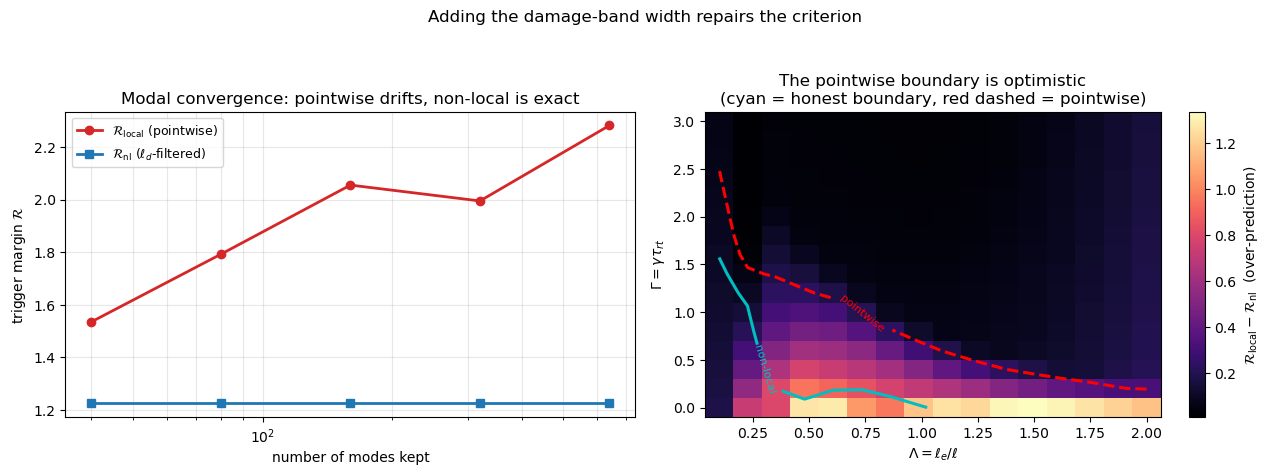

In [20]:
# ---------------------------------------------------------------------------
# 10a. Convergence of the two margins, and the two R = 1 boundaries compared.
# ---------------------------------------------------------------------------
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "problems":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from problems import secondary as sc

OUT = ROOT / "output"; OUT.mkdir(exist_ok=True)
e_crit_val = 1.3
print(f"band width tied to the threshold:  ell_d = 1/e_crit^2 = {sc.damage_band_width(e_crit_val):.3f} * ell_e\n")

# --- (i) convergence under modal refinement --------------------------------
n_modes = [40, 80, 160, 320, 640]
Rl, Rn = [], []
for nm in n_modes:
    r = sc.run_fast(0.2, 0.0, e_crit_val, n_modes=nm)
    Rl.append(sc.R_local(r)); Rn.append(sc.R_nonlocal(r))
print(f"{'n_modes':>8} {'R_local':>9} {'R_nonlocal':>11}")
for nm, a, b in zip(n_modes, Rl, Rn):
    print(f"{nm:8d} {a:9.4f} {b:11.4f}")
print("\n-> the pointwise margin drifts (Gibbs at x = ell); the non-local one is exact.")

# --- (ii) both boundaries in the (Lambda, Gamma) plane ----------------------
Lams = np.linspace(0.1, 2.0, 16)
Gams = np.linspace(0.0, 3.0, 16)
R_loc, R_nl = sc.margin_fields(Lams, Gams, e_crit_val, verbose=False)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))
axL.semilogx(n_modes, Rl, "o-", color="tab:red", lw=2, label=r"$\mathcal{R}_{\rm local}$ (pointwise)")
axL.semilogx(n_modes, Rn, "s-", color="tab:blue", lw=2, label=r"$\mathcal{R}_{\rm nl}$ ($\ell_d$-filtered)")
axL.set_xlabel("number of modes kept"); axL.set_ylabel(r"trigger margin $\mathcal{R}$")
axL.set_title("Modal convergence: pointwise drifts, non-local is exact")
axL.legend(fontsize=9); axL.grid(alpha=0.3, which="both")

pc = axR.pcolormesh(Lams, Gams, R_loc - R_nl, shading="auto", cmap="magma")
fig.colorbar(pc, ax=axR, label=r"$\mathcal{R}_{\rm local}-\mathcal{R}_{\rm nl}$  (over-prediction)")
c1 = axR.contour(Lams, Gams, R_loc, levels=[1.0], colors="r", linewidths=2.2, linestyles="--")
c2 = axR.contour(Lams, Gams, R_nl,  levels=[1.0], colors="c", linewidths=2.2)
axR.clabel(c1, fmt={1.0: "pointwise"}, fontsize=8)
axR.clabel(c2, fmt={1.0: "non-local"}, fontsize=8)
axR.set_xlabel(r"$\Lambda=\ell_e/\ell$"); axR.set_ylabel(r"$\Gamma=\gamma\tau_{rt}$")
axR.set_title("The pointwise boundary is optimistic\n(cyan = honest boundary, red dashed = pointwise)")
fig.suptitle("Adding the damage-band width repairs the criterion", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.94])
for ext in ("png", "pdf"):
    fig.savefig(OUT / f"secondary_nonlocal_criterion.{ext}", dpi=150, bbox_inches="tight")
print("\nsaved", OUT / "secondary_nonlocal_criterion.png")
frac = (R_loc >= 1.0).mean() - (R_nl >= 1.0).mean()
print(f"the pointwise test declares a secondary crack over {frac*100:.0f}% more of the "
      f"(Lambda,Gamma) plane than the non-local one")
plt.show()

**Reading it.** *Left:* the pointwise margin climbs with every mode we add — there is no converged number to quote — while the $\ell_d$-filtered margin returns the *same* value to four digits from 40 modes upward. The band width acts as the physical regulariser the pointwise test was missing. *Right:* the cyan (non-local) boundary sits **inside** the red dashed (pointwise) one everywhere: the original criterion claims secondary cracking over a visibly larger slice of the $(\Lambda,\Gamma)$ plane. The colour shows by how much — the over-prediction is largest at small $\Lambda$ and small $\Gamma$, precisely where the un-damped pulse builds the sharpest spike at the symmetry plane.

**Consequence for §7.** The regime maps of §7 are drawn with the pointwise margin, so their $\mathcal R=1$ contours should be read as an **upper bound** on the secondary-cracking region. Everything below re-runs on the non-local margin.

---

# 11. Bounding the useful window: how strong can the overshoot ever be?

*(open question 3 of §9)*

A second crack needs the dynamic strain to beat $e_{crit}$. Damping only ever *reduces* the strain, so the most generous case is the **undamped limit** $\Gamma\to0$. Define the largest overshoot the geometry can ever produce,

$$ A(\Lambda)\;:=\;\max_{x\ge x_{\rm excl},\,t}\ \frac{|e(x,t)|}{\theta}\Bigg|_{\Gamma=0} , $$

(computed on the *non-local* strain of §10, so it is a converged number). Then

$$ \boxed{\ \text{a second crack is possible at all}\iff \frac{e_{crit}}{\theta}<A(\Lambda).\ } $$

This is a hard ceiling: no choice of damping can rescue a film whose threshold sits above $A$. Translating to the third control parameter — with $\ell_e=\theta=1$ we have $\ell=1/\Lambda$, $\ell_d=\hat\ell\,\ell$ and $e_{crit}=1/\sqrt{\ell_d}=\sqrt{\Lambda/\hat\ell}$, so the condition becomes a **minimum damage length**

$$ \hat\ell\;>\;\hat\ell_{\min}(\Lambda)=\frac{\Lambda}{A(\Lambda)^{2}} . $$

Below that curve the film is simply too tough (too fine a damage band) for the released pulse ever to re-crack it.

saved /home/sajjad/Internship-2026/output/secondary_overshoot_bound.png
peak ceiling  A = 1.632  at Lambda = 0.323 (ell/ell_e = 3.1)
A drops below 1 (no overshoot beyond the pre-stress) for Lambda > 1.74


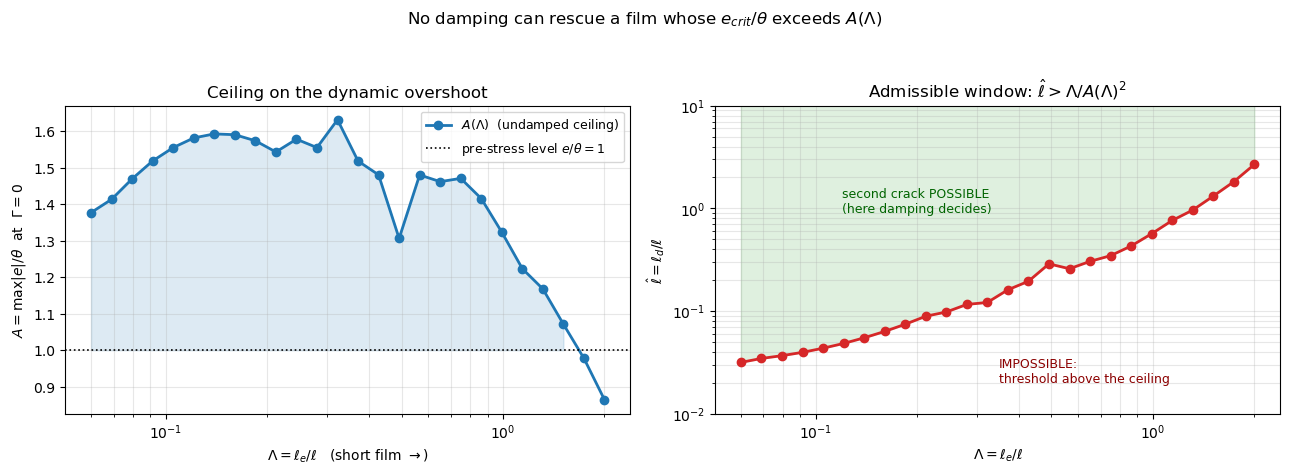

In [21]:
# ---------------------------------------------------------------------------
# 11a. The undamped overshoot ceiling A(Lambda) and the admissible window.
# ---------------------------------------------------------------------------
Lam_axis = np.geomspace(0.06, 2.0, 26)
A = sc.overshoot_undamped(Lam_axis, e_crit=e_crit_val, verbose=False)
lh_min = sc.l_hat_min(Lam_axis, A)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
ax1.semilogx(Lam_axis, A, "o-", color="tab:blue", lw=2, label=r"$A(\Lambda)$  (undamped ceiling)")
ax1.axhline(1.0, color="k", ls=":", lw=1.2, label=r"pre-stress level $e/\theta=1$")
ax1.fill_between(Lam_axis, 1.0, A, where=(A > 1.0), color="tab:blue", alpha=0.15)
ax1.set_xlabel(r"$\Lambda=\ell_e/\ell$   (short film $\to$)")
ax1.set_ylabel(r"$A=\max|e|/\theta$  at  $\Gamma=0$")
ax1.set_title("Ceiling on the dynamic overshoot")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3, which="both")

ax2.loglog(Lam_axis, lh_min, "o-", color="tab:red", lw=2)
ax2.fill_between(Lam_axis, lh_min, 10.0, color="tab:green", alpha=0.15)
ax2.text(0.12, 0.9, "second crack POSSIBLE\n(here damping decides)", fontsize=9, color="darkgreen")
ax2.text(0.35, 0.02, "IMPOSSIBLE:\nthreshold above the ceiling", fontsize=9, color="darkred")
ax2.set_ylim(1e-2, 10.0)
ax2.set_xlabel(r"$\Lambda=\ell_e/\ell$")
ax2.set_ylabel(r"$\hat\ell=\ell_d/\ell$")
ax2.set_title(r"Admissible window: $\hat\ell>\Lambda/A(\Lambda)^2$")
ax2.grid(alpha=0.3, which="both")

fig.suptitle(r"No damping can rescue a film whose $e_{crit}/\theta$ exceeds $A(\Lambda)$", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.94])
for ext in ("png", "pdf"):
    fig.savefig(OUT / f"secondary_overshoot_bound.{ext}", dpi=150, bbox_inches="tight")
print("saved", OUT / "secondary_overshoot_bound.png")
i = int(np.argmax(A))
print(f"peak ceiling  A = {A[i]:.3f}  at Lambda = {Lam_axis[i]:.3f} (ell/ell_e = {1/Lam_axis[i]:.1f})")
print(f"A drops below 1 (no overshoot beyond the pre-stress) for Lambda > "
      f"{Lam_axis[A < 1.0].min() if (A < 1.0).any() else float('nan'):.2f}")
plt.show()

**Reading it.** *Left:* the ceiling is **modest** — the released pulse never amplifies the strain beyond $\approx1.6\,\theta$, and only in a window of intermediate $\Lambda$ (long-but-not-endless films). For short films ($\Lambda\gtrsim1.4$) the ceiling falls **below the pre-stress level itself**: the first crack has already de-stressed the whole fragment (the $\tanh$ saturation of §2.3), so there is nothing left to amplify and a second crack is impossible whatever the material. *Right:* the same statement as a window in $(\Lambda,\hat\ell)$. The green region is where a second crack is even conceivable; inside it, damping ($\Gamma$) then decides. This is the "useful range" the note asked for — and it explains why the §6–§8 studies had to push $e_{crit}/\theta$ into the narrow band $1<e_{crit}/\theta\lesssim1.6$ to see anything interesting.

---

# 12. The fragmentation cascade

*(open question 4 of §9)*

Once a second crack forms, the film is no longer one specimen: it is a set of **new, shorter fragments**, each of which can be fed back through the very same analysis. That turns the single yes/no rule into a **cascade** and predicts where fragmentation *stops*.

**What is fixed and what changes.** The material and loading are fixed: $\ell_e$, the *physical* damping rate $\gamma$, and $e_{crit}$ (hence $\ell_d$). What changes fragment by fragment is the geometry. A fragment of full length $F$ is traction-free at both ends, so its mirror plane sits at $F/2$ and it is analysed as a half-specimen of length $L=F/2$:

$$ \Lambda=\frac{\ell_e}{L},\qquad \Gamma=\gamma\,\tau_{rt}=\gamma\,\frac{2\sqrt2\,L}{c}. $$

Note the **competition**: a shorter fragment has a *larger* $\Lambda$ (less stored energy to release — bad for cracking) but a *smaller* $\Gamma$ (fewer decay times per round trip — good for cracking). The cascade continues until the first effect wins.

**Splitting rule.** The half-specimen analysis returns one crack site $x^*$; by mirror symmetry that is *two* cracks in the full fragment, at $x^*$ and $F-x^*$. In practice $x^*$ lands **exactly on the mirror plane** every time (the strain antinode of §6), so the two merge into a single central crack and the fragment simply **halves**. This *derives* the successive-halving picture of thin-film fragmentation rather than assuming it.

  [cascade] generation 0: 1 -> 2 fragments (1 cracked)
  [cascade] generation 1: 2 -> 4 fragments (2 cracked)
  [cascade] generation 2: 4 -> 8 fragments (4 cracked)
  [cascade] generation 3: 8 -> 8 fragments (0 cracked)

final fragment lengths: [4. 4. 4. 4. 4. 4. 4. 4.]
crack sites relative to the mirror plane (should be ~0 = the antinode):
   F= 32.00  Lambda=0.062  Gamma=0.226  R_nl=1.032  L-x* = 0
   F= 16.00  Lambda=0.125  Gamma=0.113  R_nl=1.200  L-x* = 0
   F= 16.00  Lambda=0.125  Gamma=0.113  R_nl=1.200  L-x* = 0
   F=  8.00  Lambda=0.250  Gamma=0.057  R_nl=1.136  L-x* = 0

saved /home/sajjad/Internship-2026/output/secondary_cascade.png


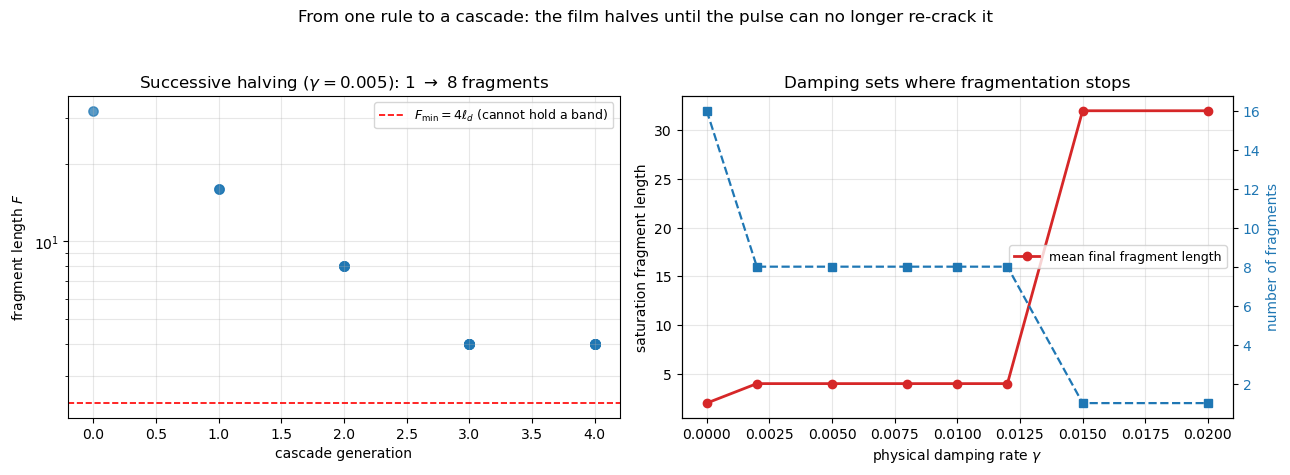

In [22]:
# ---------------------------------------------------------------------------
# 12a. Run the cascade and find where fragmentation saturates.
# ---------------------------------------------------------------------------
casc = sc.cascade(F0=32.0, gamma_phys=0.005, e_crit=e_crit_val, verbose=True)
print("\nfinal fragment lengths:", np.round(np.sort(casc["final"]), 3))
print("crack sites relative to the mirror plane (should be ~0 = the antinode):")
for ev in casc["events"][:4]:
    print(f"   F={ev['F']:6.2f}  Lambda={ev['Lambda']:.3f}  Gamma={ev['Gamma']:.3f}  "
          f"R_nl={ev['R']:.3f}  L-x* = {ev['F']/2 - ev['x_crack']:.3g}")

# how far the cascade runs, as a function of the physical damping
gammas = np.array([0.0, 0.002, 0.005, 0.008, 0.010, 0.012, 0.015, 0.020])
n_frag, F_fin = [], []
for gp in gammas:
    c_ = sc.cascade(F0=32.0, gamma_phys=float(gp), e_crit=e_crit_val, verbose=False)
    n_frag.append(len(c_["final"])); F_fin.append(c_["final"].mean())
n_frag = np.array(n_frag); F_fin = np.array(F_fin)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
for gen, frs in enumerate(casc["history"]):
    ax1.scatter([gen] * len(frs), frs, s=45, color="tab:blue", alpha=0.75)
ax1.axhline(4 * casc["ell_d"], color="r", ls="--", lw=1.2,
            label=r"$F_{\min}=4\ell_d$ (cannot hold a band)")
ax1.set_xlabel("cascade generation"); ax1.set_ylabel("fragment length $F$")
ax1.set_yscale("log")
ax1.set_title(fr"Successive halving ($\gamma={casc['gamma_phys']}$): "
              fr"{len(casc['history'][0])} $\to$ {len(casc['final'])} fragments")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3, which="both")

ax2.plot(gammas, F_fin, "o-", color="tab:red", lw=2, label="mean final fragment length")
ax2.set_xlabel(r"physical damping rate $\gamma$")
ax2.set_ylabel("saturation fragment length")
ax2b = ax2.twinx()
ax2b.plot(gammas, n_frag, "s--", color="tab:blue", lw=1.6, label="number of fragments")
ax2b.set_ylabel("number of fragments", color="tab:blue")
ax2b.tick_params(axis="y", labelcolor="tab:blue")
ax2.set_title("Damping sets where fragmentation stops")
ax2.grid(alpha=0.3); ax2.legend(fontsize=9, loc="center right")

fig.suptitle("From one rule to a cascade: the film halves until the pulse can no longer re-crack it",
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.94])
for ext in ("png", "pdf"):
    fig.savefig(OUT / f"secondary_cascade.{ext}", dpi=150, bbox_inches="tight")
print("\nsaved", OUT / "secondary_cascade.png")
plt.show()

**Reading it.** *Left:* every surviving fragment halves, generation after generation, until it hits the floor where the released pulse can no longer reach $e_{crit}$ — the cascade **terminates by itself** at a characteristic fragment length. Nothing about halving was put in by hand: it comes out because the overshoot maximum always sits on the mirror plane. *Right:* increasing the physical damping $\gamma$ stops the cascade earlier — fewer, longer fragments — and beyond $\gamma\approx0.015$ the very first fragment never cracks, so the film keeps its single crack.

**This is the semi-analytic fragmentation law the note was after:** a saturation fragment size set by the competition between $\Lambda$ (energy available) and $\Gamma$ (energy surviving the round trip), with the damage length $\ell_d$ providing the hard floor. It reproduces the experimentally familiar fact that thin-film crack spacing *saturates* instead of refining indefinitely.

> **Caveat, stated honestly.** Each generation is analysed as a *fresh* problem: the fragment starts from a uniformly pre-stressed state with traction-free ends and zero velocity. In reality the daughter fragments inherit the vibration of the parent, and the cracks appear sequentially rather than simultaneously. So the cascade predicts the *saturation length* well but should not be read as a literal time history.

---

# 13. What the modal picture cannot show: real cracks that split the film

Everything up to here answers **"would a second crack form?"** — and then keeps propagating the wave as if nothing had happened. That is a structural limitation, not an oversight: the modal solution of §3–§4 expands the transient on the eigenfunctions of a **fixed** domain, so its boundary conditions can never change.

But the moment a secondary crack nucleates at $x_c$, the physics changes completely:

1. the fragment **splits** into $[0,x_c]$ and $[x_c,\ell]$;
2. **two new traction-free faces** appear at $x_c$;
3. each face sheds its own stress and **launches a fresh release wave** into its own sub-fragment — the very same Step-1 problem, restarted on a smaller domain;
4. those waves can nucleate a **third generation** of cracks, and so on.

To see that, this section swaps the modal expansion for a **direct time integration** ([`problems/secondary_wave.py`](secondary_wave.py)) of the same equation

$$ m\,u_{tt}+\eta\,u_t-E_h\,u_{xx}+k\,u=0 $$

on a P1 finite-element grid with lumped mass. The trick is that **a crack is just a broken element**: set its internal force to zero forever and the two sides decouple, both new faces becoming traction-free automatically. *Domain splitting therefore needs no special code at all* — it falls out of the discretisation.

**Rules of the experiment** (identical physics to the note):
- $x=0$ is the first crack, traction-free from $t=0$; $x=\ell$ is the symmetry plane ($u=0$). If the criterion is met there, the **symmetry plane itself cracks** (a genuine crack at the centre of the full specimen) and the constraint is *released*, so the fragment becomes free–free. This is the usual first secondary crack, because $x=\ell$ is a strain antinode (§6).
- an intact element cracks when $|e|\ge e_{crit}$, provided it is at least one band width $\ell_d=1/e_{crit}^2$ from every existing crack — two cracks cannot overlap. **No exclusion zone is imposed**: the only spacing rule is the physical one from §10.

**Two checks the solver must pass first** (the cell below prints them):
- with cracking switched **off** it must reproduce the modal solution — it agrees to $\sim0.1\%$ on the elastic-energy history. (Compare the *energy*, not the pointwise field: the two differ visibly only at the sharp release front, which is exactly where the truncated cosine series rings — the Gibbs effect of §10.)
- with cracking **on**, the total energy $\mathcal K+\mathcal P_{el}+\mathcal P_f+\mathcal D+\mathcal S$ must stay constant. It does, to $\lesssim0.3\%$.

verify vs modal (no cracking)  Lambda=0.3, Gamma=0.4: elastic-energy history differs by 0.09%
verify vs modal (no cracking)  Lambda=0.2, Gamma=0.0: elastic-energy history differs by 0.20%

  Lambda=0.20  Gamma=2.20  ->  0 secondary crack(s), 0 generation(s)   [energy conserved to 0.00%]
  Lambda=0.20  Gamma=1.40  ->  2 secondary crack(s), 1 generation(s)   [energy conserved to 0.08%]
  Lambda=0.20  Gamma=0.50  ->  6 secondary crack(s), 3 generation(s)   [energy conserved to 0.25%]
  Lambda=1.50  Gamma=0.50  ->  0 secondary crack(s), 0 generation(s)   [energy conserved to 0.00%]
  Lambda=1.00  Gamma=0.50  ->  1 secondary crack(s), 1 generation(s)   [energy conserved to 0.19%]
  Lambda=0.20  Gamma=0.50  ->  6 secondary crack(s), 3 generation(s)   [energy conserved to 0.25%]
saved /home/sajjad/Internship-2026/output/secondary_wave_spacetime.png | common colour scale 0 .. 1.885


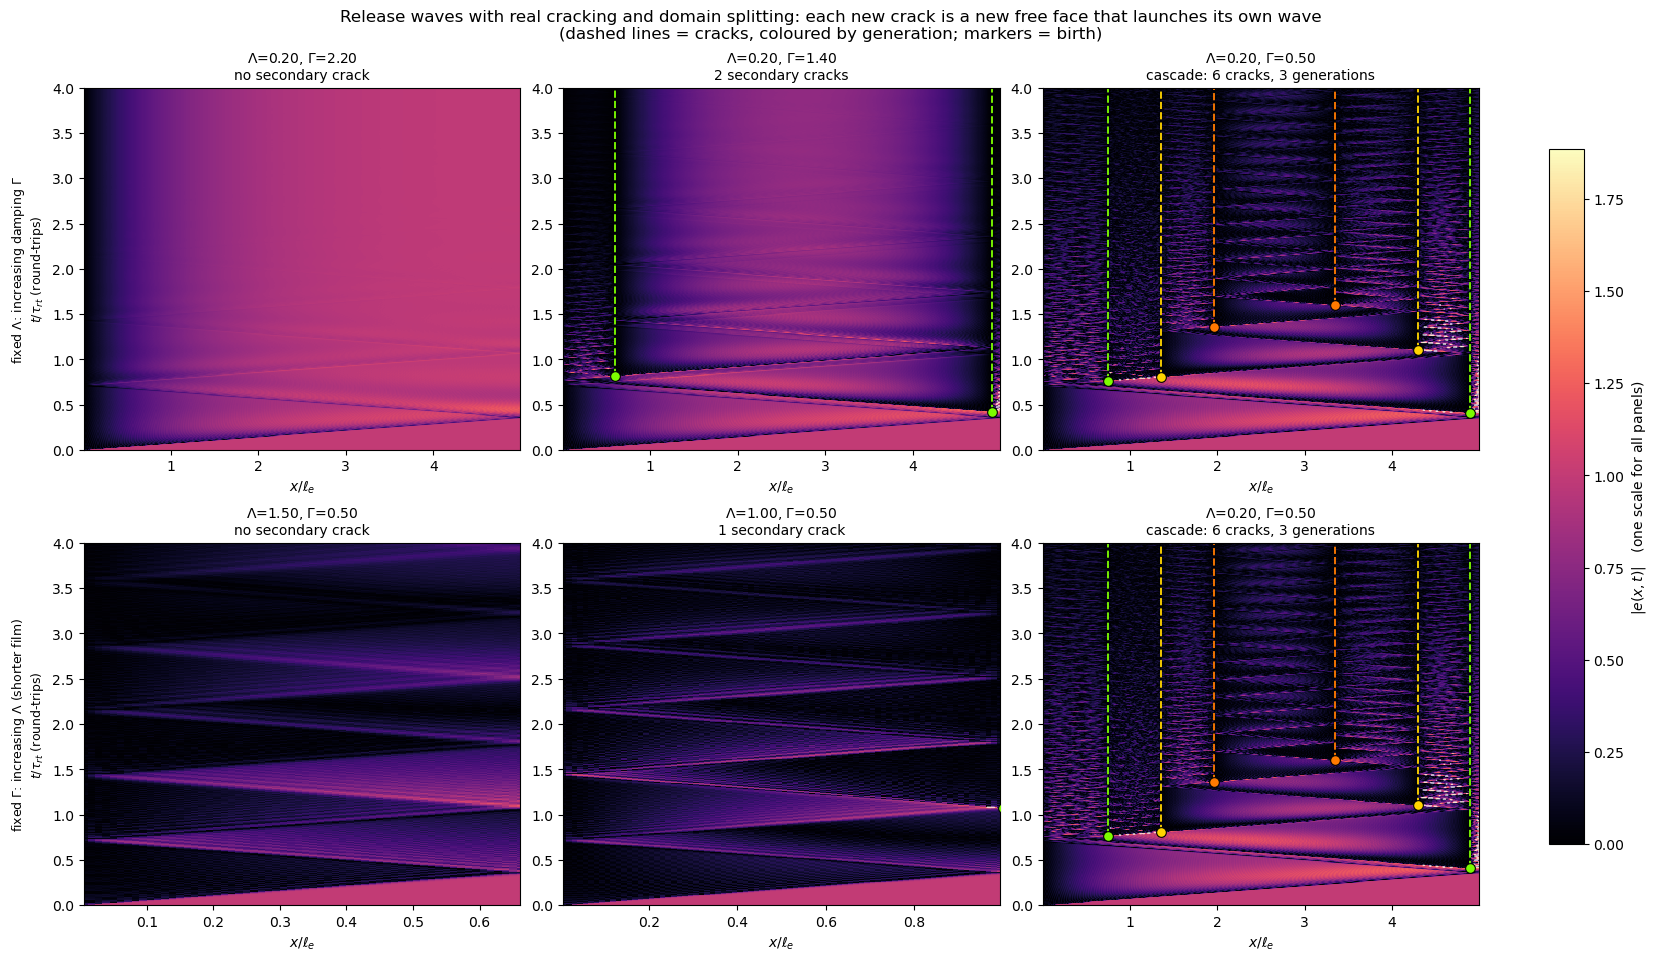

saved /home/sajjad/Internship-2026/output/secondary_wave_energy.png


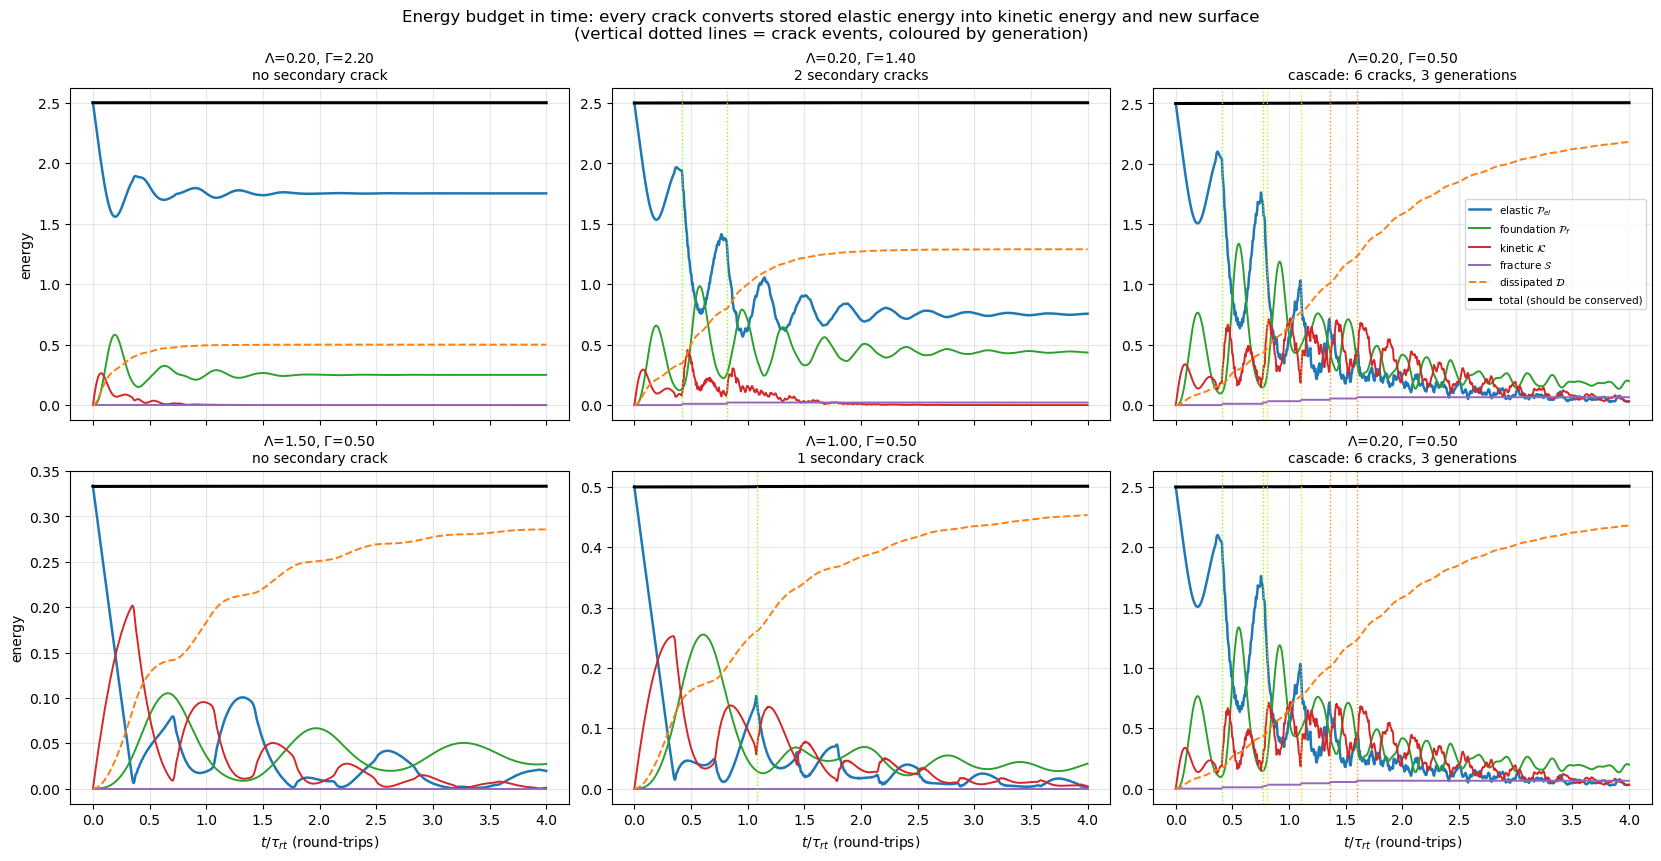

In [23]:
# ---------------------------------------------------------------------------
# 13a. Six runs: three along a vertical line (fixed Lambda, more damping) and
#      three along a horizontal line (fixed Gamma, shorter film).  In each
#      triple: no crack / secondary cracks / a full multi-generation cascade.
# ---------------------------------------------------------------------------
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "problems":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from problems import secondary_wave as sw

OUT = ROOT / "output"; OUT.mkdir(exist_ok=True)

# --- check 1: does the direct solver reproduce the modal solution? ----------
for Lam, Gam in [(0.3, 0.4), (0.2, 0.0)]:
    chk = sw.verify_against_modal(Lam, Gam, cells_per_ell_e=120)
    print(f"verify vs modal (no cracking)  Lambda={Lam}, Gamma={Gam}: "
          f"elastic-energy history differs by {chk['rel_err']:.2%}")

# --- the six points ---------------------------------------------------------
POINTS = [(0.20, 2.20), (0.20, 1.40), (0.20, 0.50),    # top row:    fixed Lambda
          (1.50, 0.50), (1.00, 0.50), (0.40, 0.50)]    # bottom row: fixed Gamma
runs = []
print()
for Lam, Gam in POINTS:
    r = sw.simulate(Lam, Gam, e_crit=1.3, n_roundtrips=4.0, cells_per_ell_e=80)
    drift = abs(r["hist"]["total"][-1] - r["hist"]["total"][0]) / r["hist"]["total"][0]
    print(f"  Lambda={Lam:.2f}  Gamma={Gam:.2f}  ->  {r['n_secondary']} secondary crack(s), "
          f"{r['n_generations']} generation(s)   [energy conserved to {drift:.2%}]")
    runs.append(r)

sw.plot_wave_spacetime(runs, OUT)
plt.show()
sw.plot_wave_energy(runs, OUT)
plt.show()

### 13b. Reading the two figures

**Space-time maps.** Read each panel bottom-to-top as time. The bright diagonal band leaving $x=0$ at $t=0$ is the first release wave; it reflects off the ends and criss-crosses. A dashed line is a **crack**, drawn from the instant it is born (marker) upward, coloured by **generation** — green = 1st, yellow = 2nd, orange = 3rd. Two things are worth staring at:

- **Each crack casts a "shadow".** Immediately to either side of a new dashed line the map goes dark: that is the new traction-free face shedding its stress over a length $\ell_e$. The dark wedge spreading away from the marker *is* the new release wave — the Step-1 problem restarting on a smaller fragment.
- **The fragments then ring independently.** After the split, each piece has its own round-trip time, so the fine criss-cross pattern gets *denser* in the short fragments — visible as the tight vertical striping between closely-spaced cracks. This is precisely the picture that cannot exist in the fixed-domain modal solution.

**Row 1 — damping.** At $\Gamma=2.2$ the pulse dies before it can do anything: no secondary crack. At $\Gamma=1.4$ it survives just long enough to break the film, but the fragments it leaves are too quiet to break again — a **single generation**. At $\Gamma=0.5$ the released energy survives many reflections and the film breaks, breaks again, and again: a **three-generation cascade**.

**Row 2 — geometry.** At $\Lambda=1.5$ (a film shorter than $\ell_e$) the first crack has already de-stressed the whole fragment, so there is nothing left to release (the $\tanh$ saturation of §2.3): no secondary crack. At $\Lambda=1.0$ exactly one crack forms, on the symmetry plane. At $\Lambda=0.2$ the long film carries a full transfer length's worth of energy and cascades.

**Energy histories.** The black total line is flat in every panel — the solver conserves energy, which is the strongest single check we have on it. Everything else tells the story:

- the **elastic** energy (blue) collapses at $t=0$ as the first crack relaxes the film, and drops again at every crack event (dotted vertical lines);
- the **kinetic** energy (red) is the mirror image — each drop in elastic energy becomes motion first;
- the **foundation** energy (green) rises as the film slides against the substrate;
- **dissipation** (orange, cumulative) eventually eats everything: at $\Gamma=2.2$ it absorbs the release almost immediately, which is *why* nothing cracks;
- the **fracture** energy (purple) is the elastic energy destroyed at the crack faces — small here, because in this reduced model the criterion $e_{crit}$ already encodes the cost of building a damage band (§10).

Compare the first and last panels of the top row: **the same film, the same released energy, and only the damping differs** — in one case the energy is quietly dissipated, in the other it is spent breaking the film five more times.

> **Saved for the report:** `output/secondary_wave_spacetime.*` and `output/secondary_wave_energy.*`.

> **Caveat.** The crack count is grid-converged for these six points (checked at 40–160 cells per $\ell_e$), but *marginal* parameter sets — those sitting right on the $\mathcal R=1$ boundary — can flip between neighbouring resolutions. That sensitivity is physical, not numerical noise: at the boundary the film is by definition indifferent between cracking and not.

### 13c. Watching it happen: the animation

The space-time maps compress the whole history into one static picture. To *watch* the release wave travel, cross the threshold and break the film, [`problems/secondary_wave.py`](secondary_wave.py) also has an `animate()` helper. It writes a GIF with three synchronised panels:

1. **the film itself** -- a strip coloured by $|e|$, with every existing crack drawn as a bright vertical line (coloured by generation), so the fragmentation is literally visible as the strip breaking into pieces;
2. **the strain profile** $|e(x,t)|$ against the threshold. The peak is marked, and the moment it reaches $e_{crit}$ the marker turns **red**, the area above the threshold is filled red and a **"CRITICAL -- a crack is nucleating here"** banner appears -- so the instant a point goes critical is unmistakable;
3. **the energy budget** with a moving time cursor, so every crack event can be read off the elastic/kinetic exchange at the same instant.

Two movies are produced: the multi-generation `cascade` case and the clean `single`-crack case.

In [ ]:
# ---------------------------------------------------------------------------
# 13c. Animations (writes GIFs to output/; a few minutes each).
# ---------------------------------------------------------------------------
for Lam, Gam, tag in [(0.20, 0.50, "cascade"), (1.00, 0.50, "single")]:
    r = sw.simulate(Lam, Gam, e_crit=1.3, n_roundtrips=2.5, cells_per_ell_e=80)
    print(f"Lambda={Lam}, Gamma={Gam}: {r['n_secondary']} crack(s), "
          f"{r['n_generations']} generation(s)")
    sw.animate_wave_run(r, OUT, fname=f"secondary_wave_movie_{tag}", n_frames=150, fps=, dpi=85)

Lambda=0.2, Gamma=0.5: 6 crack(s), 3 generation(s)
saved /home/sajjad/Internship-2026/output/secondary_wave_movie_cascade.gif  (6.5 MB, 150 frames @ 16 fps)
Lambda=1.0, Gamma=0.5: 1 crack(s), 1 generation(s)
saved /home/sajjad/Internship-2026/output/secondary_wave_movie_single.gif  (4.5 MB, 150 frames @ 16 fps)
